# RadCluster_2_1 — Graph-Based Cluster Dynamics for Irradiated Materials

A modular, **graph-based cluster-dynamics** code for radiation-induced defect populations — self-interstitial atom (SIA) loops, vacancy / He-vacancy cavities, and free interstitial helium — in crystalline solids, demonstrated on the reduced-activation ferritic–martensitic steel **EUROFER-97**.

> **Primary reference** — Ghoniem, N.M. (2026), *"A Generalized Graph-Based Cluster Dynamics Framework for Irradiated Materials"*, [`docs/Formulation/Generalized_Cluster_Dynamics.pdf`](../../../docs/Formulation/Generalized_Cluster_Dynamics.pdf). Section and equation numbers below refer to that document.

---

## 0. Two-layer architecture

RadCluster_2_1 is organised as **two layers** — the abstract-base-class / instantiation split of the formulation. Adding a new host material is a *declaration*, not a rewrite of the solver.

### Layer 1 — abstract, host-independent core  (`py_utils/core/`)

| Module | Role |
|---|---|
| `cluster_identifier` | the cluster four-tuple $\sigma=(\chi,n,p,c)$: polarity $\chi\in\{-1,+1\}$, size $n$, population $p$, composition $c$ |
| `edge_classes` | the **ten** elementary reaction-edge classes (growth, shrinkage, dissociation, recombination, annihilation, inter-population, solute-trapping, coalescence, source, sink) |
| `rag` | the Reaction Admissibility Graph $G=(V,E,\nu,k)$ — admissible vertices, edges with stoichiometric tuples, rate kernels |
| `graph_walker` | the master equation as a graph walk: $\dot c_a = G_a + \sum_r S_{ar}J_r(c) - D_a c_a$ |
| `state_layout` | the RAG-vertex $\leftrightarrow$ ODE-index map |
| `reductions/` | the logarithmic bin-moment reduction and the He Case-1 / Case-2 reductions |

The core carries **no** EUROFER or bcc-Fe assumptions.

### Layer 2 — material instantiation  (`py_utils/materials/eurofer97/`)

`build_eurofer_rag()` declares the EUROFER-97 host: its **populations**, its admissible **vertex and edge sets**, and the **P1–P8 rate kernels**. The abstract solver, the preconditioner, and the state-space reductions are inherited unchanged.

Every `RadClusterSimulation` carries the live two-layer description on `sim.material_rag` (the `ReactionAdmissibilityGraph`) and `sim.state_layout` — inspected in the **Material options** cell below.

---

## A. Solver and physics options

### Solver modes

| `SOLVER_MODE` | Description |
|---|---|
| `full_system` | C++ CVODE BDF on the full state vector. Linear solver: dense / band / GMRES / KLU. |
| `active_window` | Two independent sliding windows (one over SIA size, one over VAC size) + OpenMP-parallel RHS. Thread count is auto-picked from $N_{\rm eq}$ (override via `OMP_NUM_THREADS`). |

### Physics axes

Two **orthogonal** switches select the physics:

| Axis | Values | Meaning |
|---|---|---|
| `EQUATIONS` | `discrete` \| `bin_moment` | Per-size ODEs (master equations 83–86) vs. the logarithmic bin-moment grouping (Section 5.4). |
| `CASCADE`   | `fission`  \| `fusion`     | `fission` → He Case 2 (decoupled scalar inventory $Q_{\rm tot}$, Section 5.3). `fusion` → He Case 1 (mean-field loading $\bar\ell(m)$, Section 5.2). |

`RadClusterSimulation` accepts the `(equations, cascade)` pair or the combined `physics_option` string (`full_CD_fission`, `full_CD_fusion`, `bin_moment_CD_fission`, `bin_moment_CD_fusion`).

---

## B. Main features

| Feature | Reference | Description |
|---|---|---|
| Graph-based RHS assembly | Section 3.3 | the master equation is the host-independent graph-walking accumulator |
| Reaction Admissibility Graph | Section 2.2 | every elementary reaction is one of ten edge classes; forbidden reactions excluded at graph construction |
| Two equation formulations | Section 4 / 5.4 | *discrete* per-size ODEs or *bin-moment* logarithmic grouping |
| Two cascade source models | Section 5.2 / 5.3 | *fission* (Case 2 — decoupled scalar He) or *fusion* (Case 1 — mean-field He per class) |
| Three intra-bin shape closures | Section 5.5 | piecewise-constant ($P{=}1$), hat-function ($P{=}2$), log-normal ($P{=}3$) |
| EUROFER solute trapping | Eq. 125 | Cr, W, Mn, C, N effective reaction frequencies |
| 1D / 3D mixed transport | Section 4.2 | glissile SIA clusters with mean-free-path correction |
| ½⟨111⟩→⟨100⟩ loop-character split | [loop-conversion note](../../../docs/Formulation/loop_111_to_100_conversion.tex) | two coupled SIA loop populations + Marian junction/absorption (kinetic) and Dudarev unary (thermodynamic) ½⟨111⟩→⟨100⟩ conversion |
| C++ SUNDIALS / CVODE BDF solver | Section 6.2 | dense, banded, GMRES, or KLU linear solver |
| Woodbury preconditioner | Section 6.2 | bordered-banded Sherman–Morrison–Woodbury preconditioner for GMRES |
| Conservation diagnostics | Eqs. 96, 97 | $\delta_{\rm FP}$ (Frenkel-pair) and $\delta_{\rm He}$ (helium) |
| Timestamped outputs | — | `output/YYYYMMDD_HHMMSS_<git-hash>/` with provenance, results, summary CSV, plots |

---

## C. Control variables

Set in the main run cell, in the order shown there. Sizes are atom counts; concentrations are atomic fractions; energies in eV; temperature in K.

### C.1 Run-mode switches

| Variable | Values | Meaning |
|---|---|---|
| `DEBUG` | `True` / `False` | Print all solver / override / diagnostic messages. |
| `MATERIAL` | `'eurofer97'` | Host material — selects the Layer-2 instantiation (see §D). |
| `SOLVER_MODE` | `'full_system'` \| `'active_window'` | Time-stepping strategy. |
| `EQUATIONS` | `'discrete'` \| `'bin_moment'` | Per-size ODEs vs. bin-moment grouping. |
| `CASCADE` | `'fission'` \| `'fusion'` | Cascade spectrum + He-coupling case. |
| `HE_KINETICS` | `'quasi_steady_state'` \| `'dynamic'` | QSS eliminates the free-He variable (recommended); `dynamic` keeps $c_h$ explicit. |

### C.2 Cluster domain and mobility

| Variable | Meaning |
|---|---|
| `I`, `V` | Maximum SIA / vacancy cluster size tracked. |
| `i_mobile`, `v_mobile` | Largest mobile SIA / vacancy cluster (sets each population's `mobile_max`). |

### C.3 Discrete / bin-moment split  (`EQUATIONS = 'bin_moment'`)

| Variable | Meaning |
|---|---|
| `i_discrete`, `v_discrete` | Sizes $1\ldots$ tracked as individual ODEs; beyond that, bin moments. |
| `I_bin`, `V_bin` | Number of logarithmic bins above the discrete prefix. |
| `SHAPE_FUNCTION` | Intra-bin closure: `'constant'` ($P{=}1$), `'linear'` ($P{=}2$), `'lognormal'` ($P{=}3$). |

To recover full per-size ODEs: `EQUATIONS='discrete'`, `I_bin=0`, `V_bin=0`, `i_discrete=I`, `v_discrete=V`.

### C.4 Numerics — `SOLVER_CONFIG`

`t_span` (s), `n_points`, `log_time`, `rtol`, `atol`, and `solver_method` (`linsol` ∈ {dense, band, gmres, klu}; `preconditioner` ∈ {Jacobi, Woodbury}).

### C.5 Physics overrides — `PARAM_OVERRIDES`

Any key here replaces the value read from `input/input_parameters.xlsx` (the key is the *Symbol* column of the relevant sheet). Set `PARAM_OVERRIDES = {}` to use the workbook verbatim. Common keys: `T`, `eta`, `f_cl_i`, `f_cl_v`, `E_m_1D`, `L_hat`, `c_C`, `E_b_C_SIA`, `rho_d`, `Z_i`, `Z_ii`.

### C.6 SIA loop-character split  (`SIA_LOOP_SPLIT = True`)

| Variable | Meaning |
|---|---|
| `SIA_LOOP_SPLIT` | Split the SIA population into glissile ½⟨111⟩ + sessile ⟨100⟩ loops and run the conversion (→ `SOLVER_CONFIG['loop_conversion']`). `False` → a single ½⟨111⟩ population (legacy *im5vm2* behaviour). |
| `N_LOOP_MIN` | ⟨100⟩ loop-onset size $n_{\rm conv}$ — no ⟨100⟩ loop is tracked below this (→ `n_loop_min` override). |

The conversion **physics** knobs (barriers, crossover temperature, junction yield) live in the Excel workbook and are documented as override keys in §D below.

---

## D. ½⟨111⟩→⟨100⟩ SIA loop-character split — method and parameters

Reference — [`docs/Formulation/loop_111_to_100_conversion.tex`](../../../docs/Formulation/loop_111_to_100_conversion.tex) (Marian 2002; Dudarev 2008; Arakawa 2006).

bcc Fe and ferritic–martensitic steels grow prismatic interstitial loops of **two Burgers-vector characters**: glissile **½⟨111⟩** loops (1-D mobile to large size) and sessile **⟨100⟩** loops (square $\{100\}$ habit, essentially immobile). Displacement cascades inject almost exclusively ½⟨111⟩ clusters, so the ⟨100⟩ population must be **generated** during microstructural evolution — it grows in with dose and comes to dominate above $\sim\!550\,^{\circ}$C. Setting `SIA_LOOP_SPLIT = True` integrates **two coupled SIA populations** (`bulk-111`, `bulk-100`) and adds three additive conversion channels:

| Channel | Reaction | Carries | Source |
|---|---|---|---|
| **Unary** (thermodynamic) | $\tfrac12\langle111\rangle_n \to \langle100\rangle_n$ (size-preserving reorientation) | the **temperature** trend | Dudarev 2008 |
| **Junction** (kinetic) | $\tfrac12[111]_n + \tfrac12[\bar1\bar1\bar1]_{n'} \to [100]_{n+n'}$ | nucleation from comparable-size collisions | Marian 2002 |
| **Absorption** (kinetic) | $[100]_m + \tfrac12\langle111\rangle_n \to [100]_{m+n}$ | the dominant ⟨100⟩ **growth** route | Marian 2002 |

- **Unary** — a single ½⟨111⟩ loop reorients at rate $\Gamma_{\rm uni}(n,T)=\nu_0\,e^{-E_a^{\rm uni}(n)/k_BT}\,\max[0,\,1-e^{-\Delta F/k_BT}]$, gated by the per-loop driving force $\Delta F(n,T)=P(n)\,\Delta f(T)$.  $\Delta f$ softens as $(1-T/T_c)^{1/4}$ (the ⟨100⟩ prelogarithmic self-energy collapses as the shear constant $c'$ softens near the $\alpha$–$\gamma$ transition), so conversion turns on above a crossover temperature $T^\ast$.  The size-dependent barrier $E_a^{\rm uni}(n)=E_a^0+\gamma_a P(n)/b_{111}$ favours a preferred conversion-size window.
- **Junction** — two mobile ½⟨111⟩ loops that collide condense to a ⟨100⟩ loop only when of *comparable* size; the yield $\varphi=\varphi_{\max}\exp[-(\ln(n/n'))^2/2\sigma_s^2]\,\Theta(\min(n,n')\ge n_{j,\min})$ branches the ½⟨111⟩ coalescence kernel; the complement stays ordinary ½⟨111⟩ coalescence.
- **Absorption** — a sessile ⟨100⟩ loop captures mobile ½⟨111⟩ clusters (cross-character collision kernel driven by the ½⟨111⟩ partner, $D^{100}\!\approx\!0$).

Every channel conserves the total SIA content $\sum_n n\,c_n^{(111)} + \sum_m m\,c_m^{(100)}$ (junction/absorption products carry the summed sizes; the unary transfer is size-preserving), so the Frenkel-pair diagnostic $\delta_{\rm FP}$ is unaffected.  With `SIA_LOOP_SPLIT = False` a single ½⟨111⟩ population is integrated and post-processing reports $f_{111}\equiv1$, $N_{\langle100\rangle}=0$.

**Parameters** — workbook defaults (`input/input_parameters.xlsx`); override any via `PARAM_OVERRIDES` using the *Symbol* key:

| Symbol | Default | Meaning |
|---|---|---|
| `SIA_LOOP_SPLIT` | `True` | master on/off for the split + conversion (run cell → `loop_conversion`) |
| `N_LOOP_MIN` / `n_loop_min` | `4` | ⟨100⟩ loop-onset size $n_{\rm conv}$ |
| `E_a0_conv` | `1.8` eV | unary direct-rotation barrier offset $E_a^0$ (sets the $f_{111}(T)$ crossover) |
| `gamma_a_conv` | `0.03` eV | unary barrier size slope $\gamma_a$ (per perimeter segment) |
| `T_star_conv_C` | `450` °C | conversion crossover temperature $T^\ast$ ($\Delta F\!=\!0$), within $[350,550]$ |
| `phi_max_junc` | `0.5` | junction peak yield $\varphi_{\max}$ at $n\!=\!n'$ |
| `sigma_s_junc` | `0.35` | junction log-size tolerance $\sigma_s$ |
| `n_j_min_junc` | `30` | minimum junction size $n_{j,\min}$ (SIAs) |
| `A_100`, `B_100` | `0.716`, `0.358` | ⟨100⟩ loop thermal-emission binding-energy fit (Table 18) |

Post-processing splits every SIA observable into ½⟨111⟩ and ⟨100⟩ sub-populations: the content-weighted fraction `f_111_loop`, separate ⟨100⟩/⟨111⟩ size distributions, and TEM density / mean-size for each character.

---

## E. Material options — populations, edges, and the reaction graph

The host material (Layer 2) **declares** the Reaction Admissibility Graph the abstract core integrates. The dedicated *Material options* cell (below the run cell) inspects it:

- **Populations** — for EUROFER-97, two SIA populations `P⁺ = {bulk-111, bulk-100}` (glissile ½⟨111⟩ loops + sessile ⟨100⟩ loops, paper Eq. 12) and one vacancy `bulk` population (paper Eqs. 42–43), coupled by ½⟨111⟩→⟨100⟩ inter-population conversion edges (Marian junction/absorption + Dudarev unary). The split is toggled by `SIA_LOOP_SPLIT` in the config cell (→ `SOLVER_CONFIG['loop_conversion']`); when off, a single bulk ½⟨111⟩ SIA population is integrated.
- **Edges** — the admissible elementary reactions, each tagged with one of the ten `EdgeClass` values: recombination (P1), cavity/loop growth & shrinkage (P2/P3), fixed-sink loss (P4), thermal emission (P5), SIA–SIA & V–V coalescence, V–I annihilation, cascade source, and the trap-mutation (P7) / re-solution (P8) edges.
- **State layout** — the RAG-vertex → ODE-index map (`StateLayout`), reported as `N_eq` and the per-block index ranges.

Inspecting `sim.material_rag` shows exactly which physics is in the model — which reactions are admissible and which approximations are active.

---

## F. What gets saved

```
output/YYYYMMDD_HHMMSS_<git-hash>/
├── provenance.md       # input parameters, git SHA, solver settings
├── results.pkl         # full ODE solution
├── summary.csv         # macroscopic quantities vs. time
└── plots/              # PNG figures (+ plot_data.pkl for the replot cell)
```

The end-of-run summary prints final dose, swelling, total He, mean SIA / vacancy cluster sizes, loop and void densities, and the two conservation diagnostics $\delta_{\rm FP}$ (Eq. 96) and $\delta_{\rm He}$ (Eq. 97).

## G. Where to look next

- Permanent material / environment changes → `input/input_parameters.xlsx`.
- Abstract framework → `py_utils/core/`; EUROFER-97 instantiation → `py_utils/materials/eurofer97/`.
- Full equation reference → [`docs/Formulation/Generalized_Cluster_Dynamics.pdf`](../../../docs/Formulation/Generalized_Cluster_Dynamics.pdf).
- Implementation notes → [`RadCluster_2_1/CLAUDE.md`](../../CLAUDE.md).
- After editing C++ sources → set `FORCE_REBUILD = True` in the build cell and re-run it.

## Build C++ solver (run once after code changes)

In [6]:
import sys, os, subprocess
from pathlib import Path

# Add RadCluster_2_1 root to path
MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print(f'Module root: {MODULE_ROOT}')
print(f'Repo root:   {REPO_ROOT}')

# ---------------------------------------------------------------------------
# Build the C++ SUNDIALS solver only if the platform-correct binary is
# missing. This makes the notebook portable across macOS / Linux / Windows:
# moving between OSes leaves the wrong-platform binary in build/ and the
# Python bridge cannot launch it, so we rebuild on first run for the new OS.
# Set FORCE_REBUILD = True to force a rebuild after C++ source changes.
# The C++ sources now live under cpp_utils/core/ (host-independent solver)
# and cpp_utils/materials/eurofer97/ (EUROFER rate kernels).
# ---------------------------------------------------------------------------
FORCE_REBUILD = False

build_dir = MODULE_ROOT / 'build'
exe_name  = 'solver.exe' if sys.platform == 'win32' else 'solver'
exe_candidates = [
    build_dir / 'Release' / exe_name,
    build_dir / 'Debug'   / exe_name,
    build_dir              / exe_name,
]
exe_found = next((p for p in exe_candidates if p.exists()), None)

if exe_found is not None and not FORCE_REBUILD:
    print(f'C++ solver already built: {exe_found}')
    print('Set FORCE_REBUILD = True to rebuild after C++ source changes.')
else:
    if exe_found is None:
        print(f'No {exe_name} found under {build_dir} -- building now ...')
    else:
        print(f'FORCE_REBUILD set -- rebuilding {exe_found} ...')

    build_dir.mkdir(exist_ok=True)
    cmake_src  = MODULE_ROOT / 'cpp_utils'
    cmake_cmd  = ['cmake', '-S', str(cmake_src), '-B', str(build_dir),
                   '-DCMAKE_BUILD_TYPE=Release']
    build_cmd  = ['cmake', '--build', str(build_dir), '--config', 'Release']

    for cmd in [cmake_cmd, build_cmd]:
        res = subprocess.run(cmd, capture_output=True, text=True)
        print(' '.join(cmd))
        if res.returncode != 0:
            print('STDERR:', res.stderr[-2000:])
            raise RuntimeError(f'Build step failed: {cmd[0]} {cmd[1]}')
        else:
            print('OK')
            print(res.stdout[-500:])

    exe_found = next((p for p in exe_candidates if p.exists()), None)
    if exe_found is None:
        raise RuntimeError(f'Build completed but no {exe_name} found under {build_dir}')
    print(f'Built: {exe_found}')


Module root: /Users/ghoni/Documents/GitHub/RadCluster/RadCluster_2_1
Repo root:   /Users/ghoni/Documents/GitHub/RadCluster
C++ solver already built: /Users/ghoni/Documents/GitHub/RadCluster/RadCluster_2_1/build/solver
Set FORCE_REBUILD = True to rebuild after C++ source changes.


Applied 8 parameter overrides:
  loop_coal_pref = 3
         E_m_v = 0.72
    i_discrete = 40
    v_discrete = 5
  shape_function = linear
    n_loop_min = 4
         I_bin = 20
         V_bin = 24

Hybrid discrete + bin-moment system (shape_function='linear'):
  Discrete SIA:  i = 1..40  (40 ODEs)
  Binned SIA:    I_bin = 21  (2 moments each = 42 ODEs)
  Discrete VAC:  v = 1..5  (5 ODEs)
  Binned VAC:    V_bin = 25  (2 moments each = 50 ODEs)
  He state:      6 ODE(s)
  ──────────────────────
  Total N_eq = 143  (full_CD would be 60002)

[Segment 1] I=40000  V=20000  t=[1.00e-06, 2.11e-03]

Launching solver_mode='full_system' …
C++ solver: solver  N_eq=225  solver_mode='full_system'  physics='bin_moment_CD_fission'


[OpenMP] auto-selected 12 threads for work=60000 (N_eq=225, I+V=60000, hw_max=12)
[OpenMP_threads] 12
RadCluster_2_1 solver: N_eq=225  physics_option=2  he_mode=0  he_kinetics=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/10  t=2.34139e-06  steps=8  rhs=11  nlcf=0  etf=0  h=1.01365e-06  ret=0
[cvode] pt=2/10  t=5.482e-06  steps=10  rhs=13  nlcf=0  etf=0  h=3.955e-06  ret=0
[cvode] pt=3/10  t=1.284e-05  steps=11  rhs=15  nlcf=0  etf=0  h=7.091e-06  ret=0
[cvode] pt=4/10  t=3.005e-05  steps=14  rhs=19  nlcf=0  etf=0  h=7.091e-06  ret=0
[cvode] pt=5/10  t=7.037e-05  steps=18  rhs=26  nlcf=0  etf=1  h=9.402e-06  ret=0
[cvode] pt=6/10  t=1.648e-04  steps=22  rhs=34  nlcf=0  etf=2  h=6.383e-05  ret=0
[cvode] pt=7/10  t=3.858e-04  steps=25  rhs=38  nlcf=0  etf=2  h=6.383e-05  ret=0
[cvode] pt=8/10  t=9.032e-04  steps=30  rhs=43  nlcf=0  etf=2  h=1.356e-04  ret=0
[cvode] pt=9/10  t=2.115e-03  steps=34  rhs=52  nlcf=0  etf=3  h=4.006e-04  ret=0
[stats] steps=34 nfe=52 nni=49 nli

Reading bin file: /var/folders/j0/8q1_b2290777z28_l_0zq1340000gn/T/expanded_cd_5fdamp_m.bin (18080 bytes)
  parsed 2260 doubles -> 10 rows x 226 cols
C++ solver completed -- 10 time points
Results processing complete.
BinMomentRateEquations: i_discrete=40  I_bin=21  V_bin=25  N_eq=143  he_mode='case2'  r_i=1.413  shape_function='linear' (2 mom/bin)
  SIA bin edges (first 5): [np.int64(41), np.int64(57), np.int64(80), np.int64(113), np.int64(159), np.int64(224)]
  VAC bin edges (first 5): [np.int64(6), np.int64(8), np.int64(11), np.int64(15), np.int64(21), np.int64(29)]
  Tail OK: SIA=0.000  VAC=0.000

[Segment 2] I=40000  V=20000  t=[2.11e-03, 4.47e+00]

Launching solver_mode='full_system' …
C++ solver: solver  N_eq=225  solver_mode='full_system'  physics='bin_moment_CD_fission'


[OpenMP] auto-selected 12 threads for work=60000 (N_eq=225, I+V=60000, hw_max=12)
[OpenMP_threads] 12
RadCluster_2_1 solver: N_eq=225  physics_option=2  he_mode=0  he_kinetics=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/10  t=0.00495143  steps=24  rhs=36  nlcf=0  etf=1  h=0.000389106  ret=0
[cvode] pt=2/10  t=1.159e-02  steps=36  rhs=51  nlcf=0  etf=1  h=6.307e-04  ret=0
[cvode] pt=3/10  t=2.714e-02  steps=51  rhs=68  nlcf=0  etf=1  h=1.589e-03  ret=0
[cvode] pt=4/10  t=6.355e-02  steps=66  rhs=84  nlcf=0  etf=1  h=4.051e-03  ret=0
[cvode] pt=5/10  t=1.488e-01  steps=81  rhs=101  nlcf=0  etf=1  h=1.049e-02  ret=0
[cvode] pt=6/10  t=3.484e-01  steps=94  rhs=117  nlcf=0  etf=1  h=2.756e-02  ret=0
[cvode] pt=7/10  t=8.158e-01  steps=109  rhs=132  nlcf=0  etf=1  h=4.151e-02  ret=0
[cvode] pt=8/10  t=1.910e+00  steps=125  rhs=149  nlcf=0  etf=1  h=1.054e-01  ret=0
[cvode] pt=9/10  t=4.472e+00  steps=140  rhs=165  nlcf=0  etf=1  h=2.586e-01  ret=0
[stats] steps=140 nfe=165 

Reading bin file: /var/folders/j0/8q1_b2290777z28_l_0zq1340000gn/T/expanded_cd_1sfa46z_.bin (18080 bytes)
  parsed 2260 doubles -> 10 rows x 226 cols
C++ solver completed -- 10 time points
Results processing complete.
BinMomentRateEquations: i_discrete=40  I_bin=21  V_bin=25  N_eq=143  he_mode='case2'  r_i=1.413  shape_function='linear' (2 mom/bin)
  SIA bin edges (first 5): [np.int64(41), np.int64(57), np.int64(80), np.int64(113), np.int64(159), np.int64(224)]
  VAC bin edges (first 5): [np.int64(6), np.int64(8), np.int64(11), np.int64(15), np.int64(21), np.int64(29)]
  Tail OK: SIA=0.000  VAC=0.000

[Segment 3] I=40000  V=20000  t=[4.47e+00, 9.46e+03]

Launching solver_mode='full_system' …
C++ solver: solver  N_eq=225  solver_mode='full_system'  physics='bin_moment_CD_fission'


[OpenMP] auto-selected 12 threads for work=60000 (N_eq=225, I+V=60000, hw_max=12)
[OpenMP_threads] 12
RadCluster_2_1 solver: N_eq=225  physics_option=2  he_mode=0  he_kinetics=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/10  t=10.471  steps=34  rhs=45  nlcf=0  etf=1  h=0.429705  ret=0
[cvode] pt=2/10  t=2.452e+01  steps=59  rhs=71  nlcf=0  etf=1  h=6.535e-01  ret=0
[cvode] pt=3/10  t=5.740e+01  steps=160  rhs=211  nlcf=0  etf=9  h=9.811e-01  ret=0
[cvode] pt=4/10  t=1.344e+02  steps=248  rhs=327  nlcf=0  etf=16  h=3.617e+00  ret=0
[cvode] pt=5/10  t=3.147e+02  steps=435  rhs=597  nlcf=0  etf=41  h=1.465e+00  ret=0
[cvode] pt=6/10  t=7.368e+02  steps=625  rhs=852  nlcf=0  etf=58  h=1.534e+01  ret=0
[cvode] pt=7/10  t=1.725e+03  steps=999  rhs=1410  nlcf=6  etf=102  h=1.254e+00  ret=0
[cvode] pt=8/10  t=4.039e+03  steps=1733  rhs=2501  nlcf=6  etf=204  h=1.179e+00  ret=0
[cvode] pt=9/10  t=9.457e+03  steps=2703  rhs=3942  nlcf=43  etf=279  h=7.247e+00  ret=0
[stats] step

Reading bin file: /var/folders/j0/8q1_b2290777z28_l_0zq1340000gn/T/expanded_cd_f_9klb98.bin (18080 bytes)
  parsed 2260 doubles -> 10 rows x 226 cols
C++ solver completed -- 10 time points
Results processing complete.
BinMomentRateEquations: i_discrete=40  I_bin=21  V_bin=25  N_eq=143  he_mode='case2'  r_i=1.413  shape_function='linear' (2 mom/bin)
  SIA bin edges (first 5): [np.int64(41), np.int64(57), np.int64(80), np.int64(113), np.int64(159), np.int64(224)]
  VAC bin edges (first 5): [np.int64(6), np.int64(8), np.int64(11), np.int64(15), np.int64(21), np.int64(29)]
  Tail OK: SIA=0.000  VAC=0.000

[Segment 4] I=40000  V=20000  t=[9.46e+03, 2.00e+07]

Launching solver_mode='full_system' …
C++ solver: solver  N_eq=225  solver_mode='full_system'  physics='bin_moment_CD_fission'


[OpenMP] auto-selected 12 threads for work=60000 (N_eq=225, I+V=60000, hw_max=12)
[OpenMP_threads] 12
RadCluster_2_1 solver: N_eq=225  physics_option=2  he_mode=0  he_kinetics=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/10  t=22143.5  steps=978  rhs=1482  nlcf=15  etf=121  h=5.42586  ret=0
[cvode] pt=2/10  t=5.185e+04  steps=1683  rhs=2434  nlcf=35  etf=163  h=7.867e+01  ret=0
[cvode] pt=3/10  t=1.214e+05  steps=2477  rhs=3484  nlcf=59  etf=200  h=3.356e+02  ret=0
[cvode] pt=4/10  t=2.842e+05  steps=3267  rhs=4544  nlcf=86  etf=232  h=1.174e+03  ret=0
[cvode] pt=5/10  t=6.655e+05  steps=3503  rhs=4813  nlcf=87  etf=235  h=4.883e+03  ret=0
[cvode] pt=6/10  t=1.558e+06  steps=3514  rhs=4828  nlcf=88  etf=235  h=6.921e+05  ret=0
[cvode] pt=7/10  t=3.648e+06  steps=3515  rhs=4831  nlcf=89  etf=235  h=5.050e+06  ret=0
[cvode] pt=8/10  t=8.542e+06  steps=3571  rhs=4984  nlcf=115  etf=235  h=4.095e+05  ret=0
[cvode] pt=9/10  t=2.000e+07  steps=3577  rhs=4996  nlcf=117  etf=2

Reading bin file: /var/folders/j0/8q1_b2290777z28_l_0zq1340000gn/T/expanded_cd_j2xr9bti.bin (18080 bytes)
  parsed 2260 doubles -> 10 rows x 226 cols
C++ solver completed -- 10 time points
Results processing complete.
BinMomentRateEquations: i_discrete=40  I_bin=21  V_bin=25  N_eq=143  he_mode='case2'  r_i=1.413  shape_function='linear' (2 mom/bin)
  SIA bin edges (first 5): [np.int64(41), np.int64(57), np.int64(80), np.int64(113), np.int64(159), np.int64(224)]
  VAC bin edges (first 5): [np.int64(6), np.int64(8), np.int64(11), np.int64(15), np.int64(21), np.int64(29)]
  Tail: VAC=0.349 (max doublings reached)

Adaptive run complete: 4 segments, 0 doublings (I×0, V×0), final domain I=40000 V=20000, 37 time points saved
Saving output to: /Users/ghoni/Documents/GitHub/RadCluster/RadCluster_2_1/output/20260902_192743_full_system_bin_moment_CD_fission_I40000V20000_im5vm1
  37 time points to save
  ✓ provenance.md
  ✓ results_t.npy / results_y.npy
  ✓ summary.csv
  ✓ diagnostics.txt
plot_si

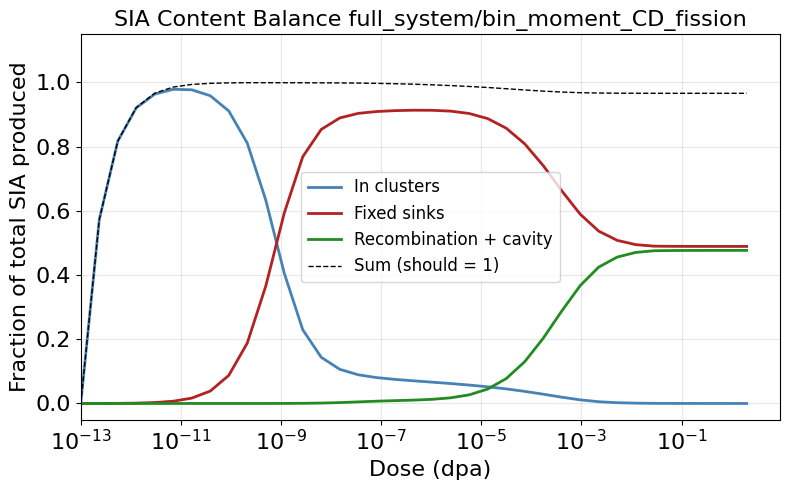

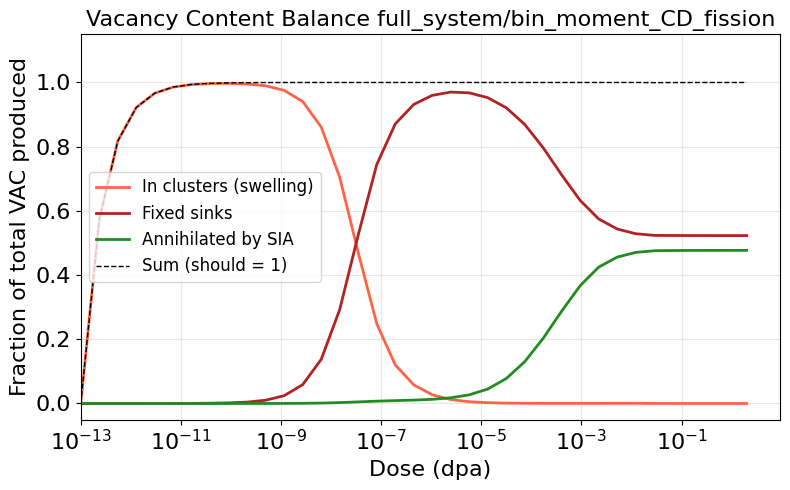

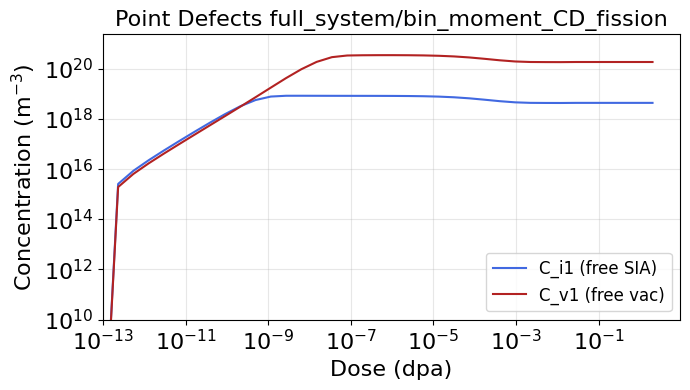

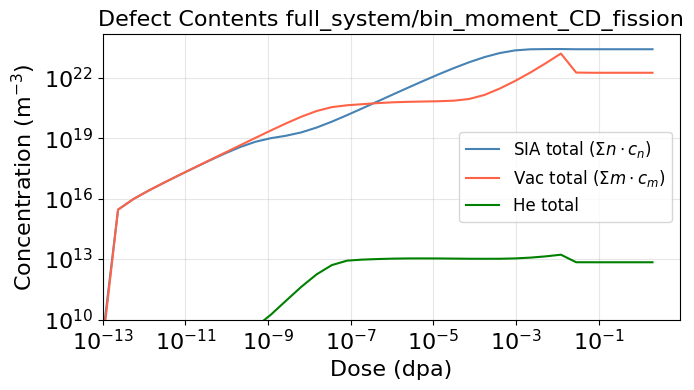

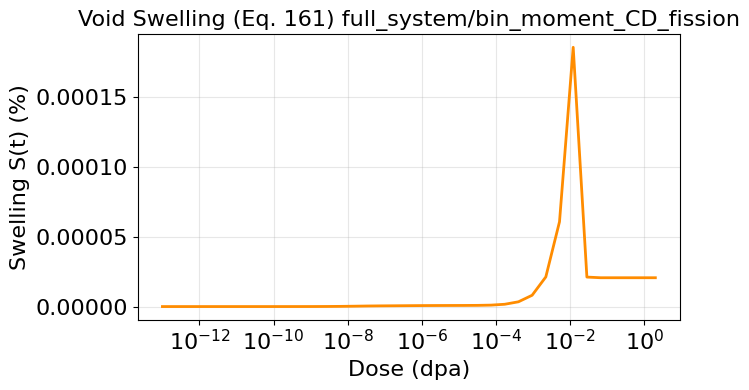

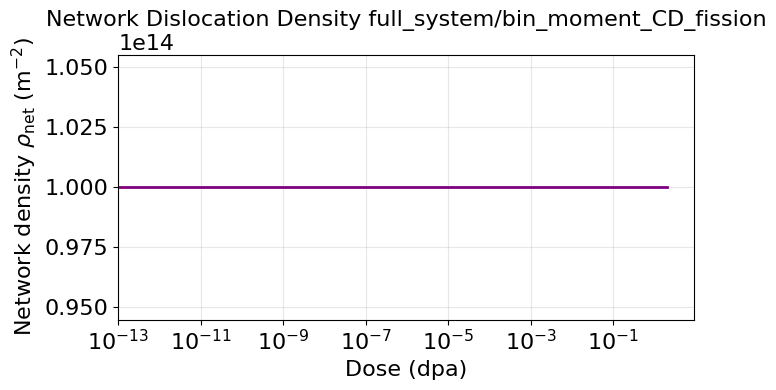

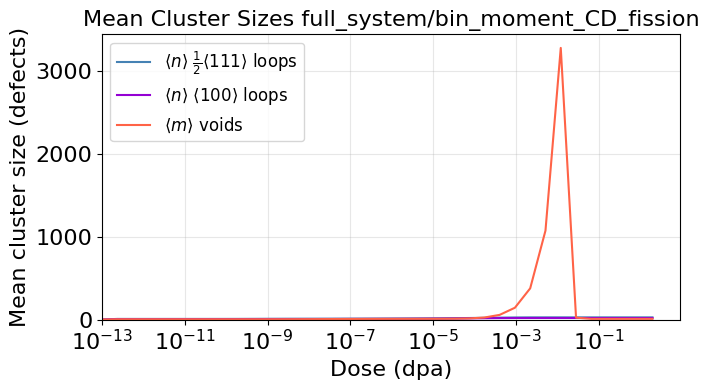

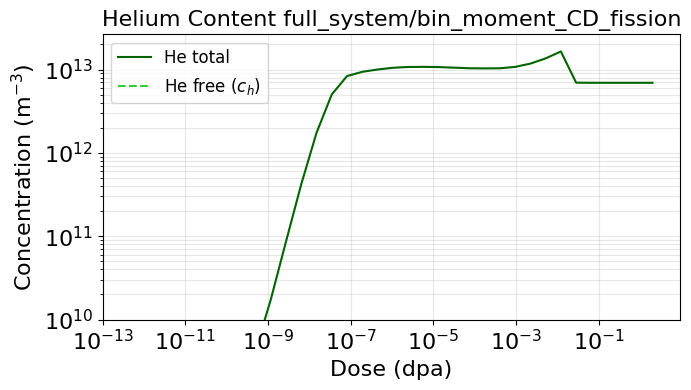

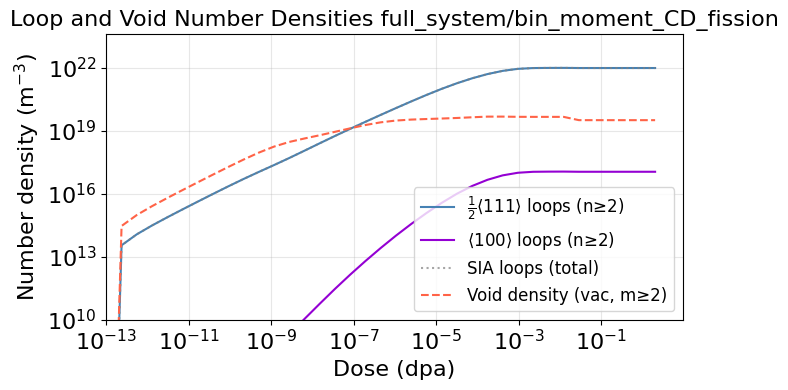

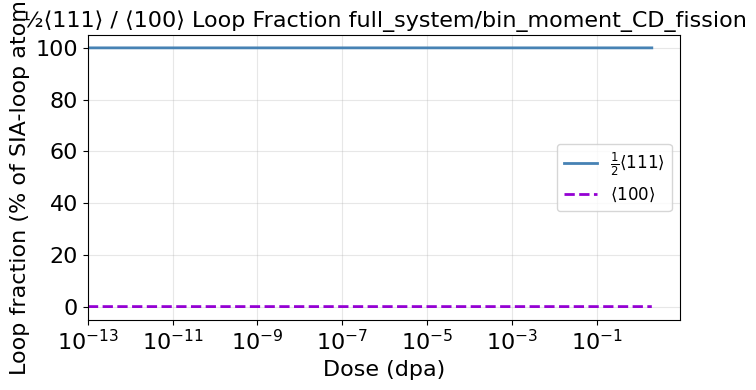

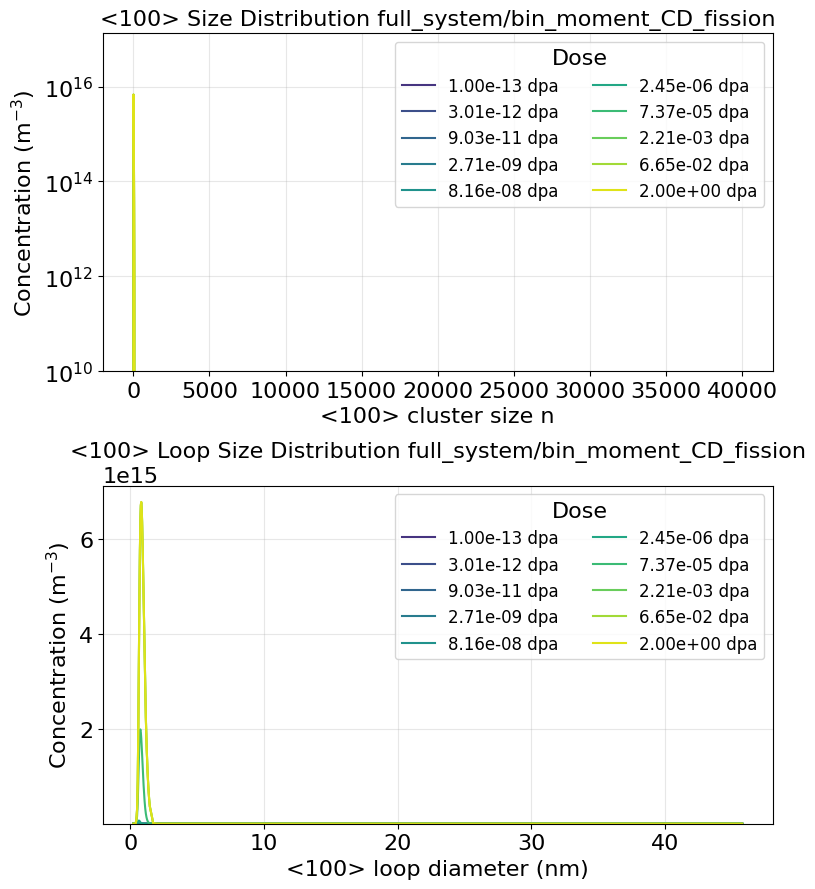

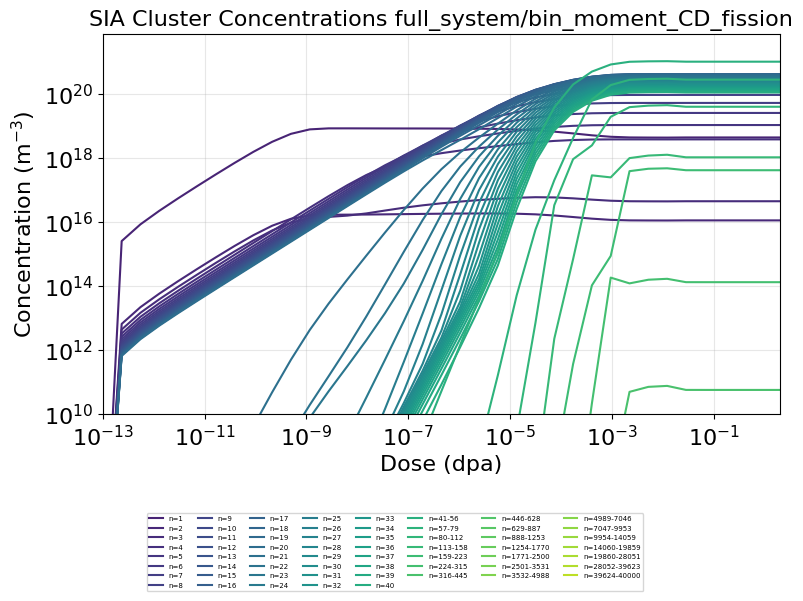

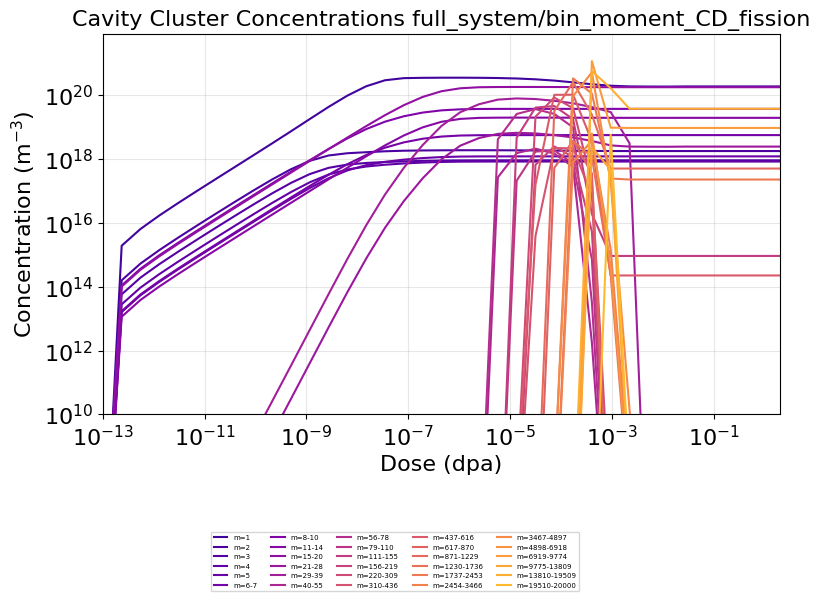

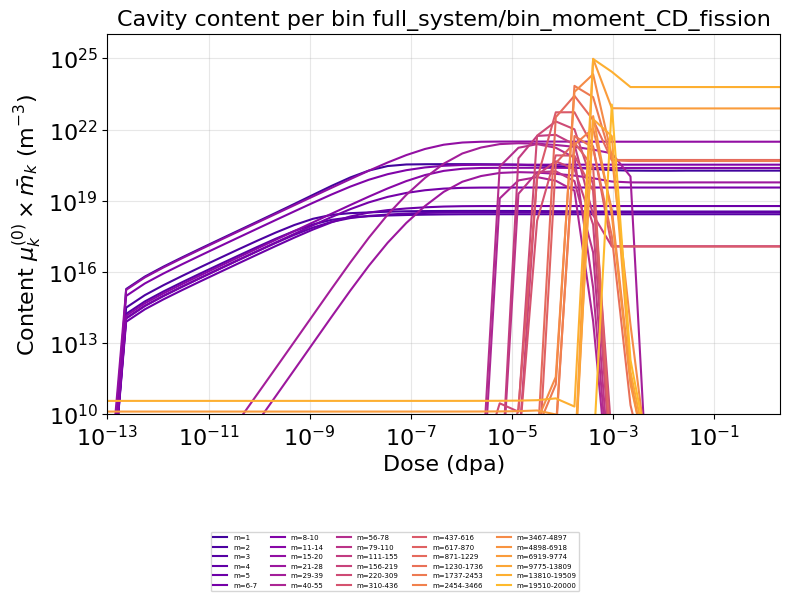

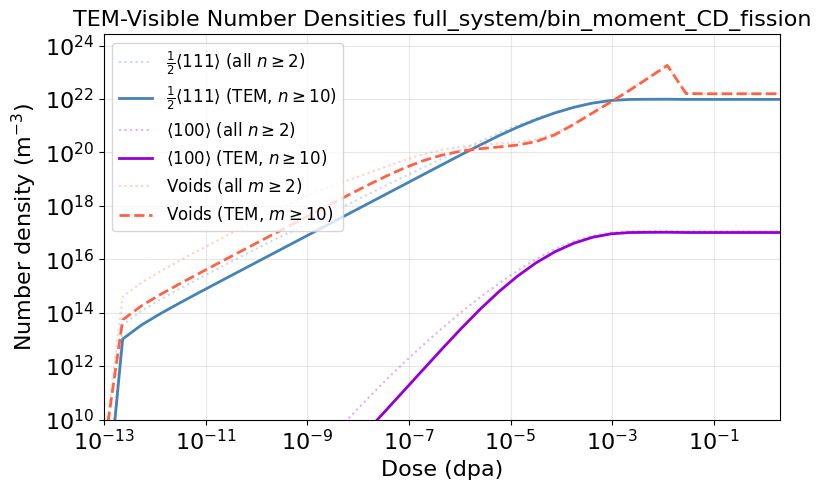

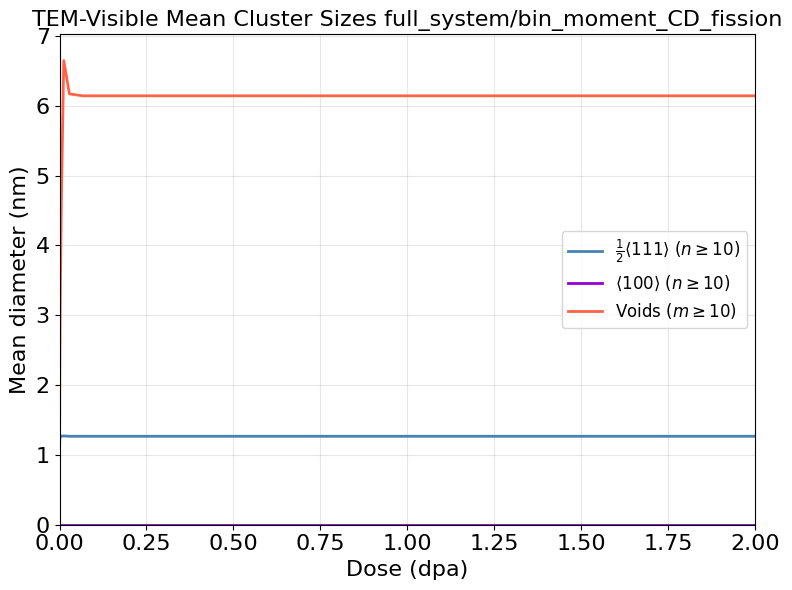

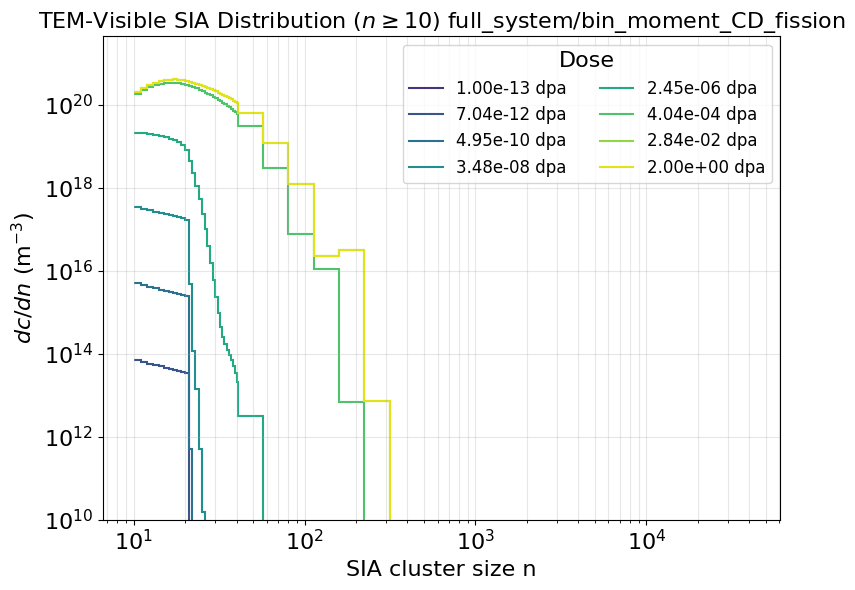

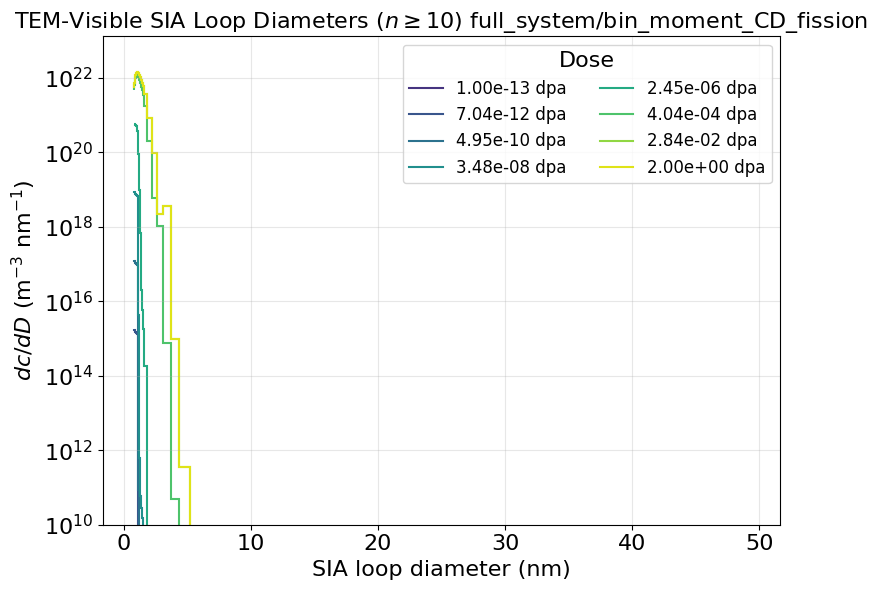

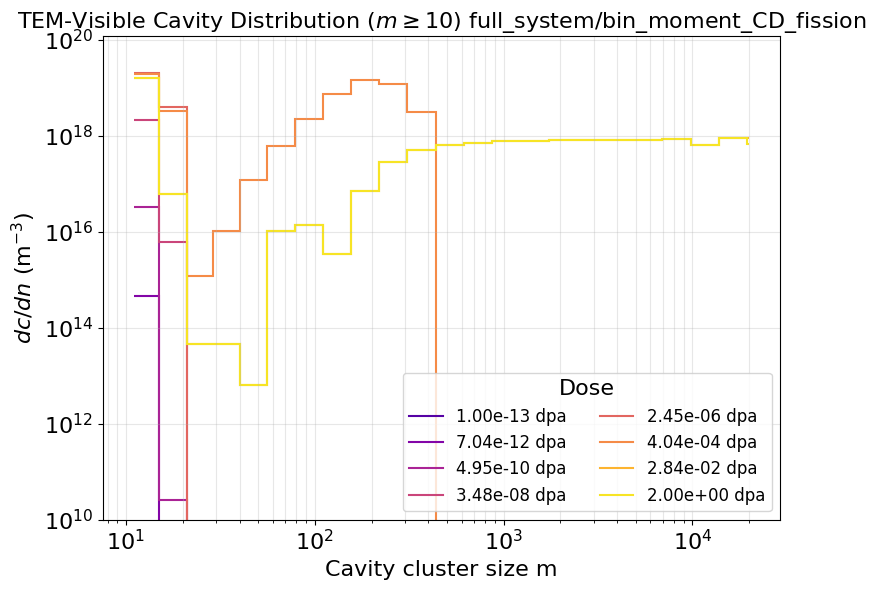

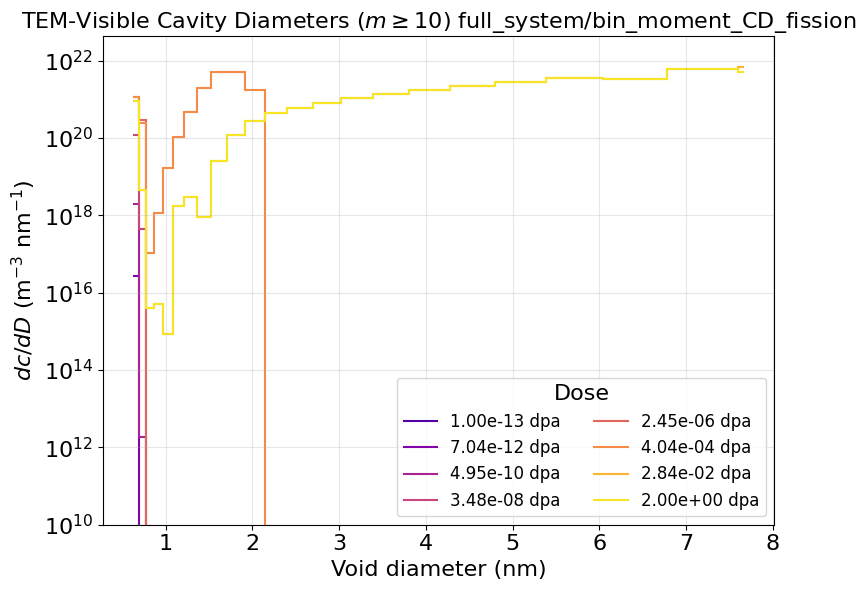

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════
import sys, os, io
# Drop machine-scope OMP_NUM_THREADS so the C++ solver auto-picks threads from N_eq
os.environ.pop('OMP_NUM_THREADS', None)
from pathlib import Path

MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import numpy as np
import importlib

# Reload all py_utils modules to pick up code changes
import RadCluster_2_1.py_utils.defect_production as _dp_mod
import RadCluster_2_1.py_utils.binding_energies as _be_mod
import RadCluster_2_1.py_utils.bin_moment_rates as _bmr
import RadCluster_2_1.py_utils.input_data as _inp_mod
import RadCluster_2_1.py_utils.reaction_rates as _rr_mod
import RadCluster_2_1.py_utils.rate_equations as _re_mod
import RadCluster_2_1.py_utils.cpp_bridge as _cb_mod
import RadCluster_2_1.py_utils.post_process as _pp_mod
import RadCluster_2_1.py_utils.simulation as _sim_mod
import RadCluster_2_1.py_utils.visualization as viz
for _m in [_dp_mod, _be_mod, _bmr, _inp_mod, _rr_mod, _re_mod,
           _cb_mod, _pp_mod, _sim_mod, viz]:
    importlib.reload(_m)
from RadCluster_2_1.py_utils.simulation import RadClusterSimulation

# ══════════════════════════════════════════════════════════════════════════════
# 1. Plot axis controls (override viz defaults; None = auto)
# ══════════════════════════════════════════════════════════════════════════════
# Three groups cover the whole plot suite:
#   concentration — concentration vs dose (point defects, totals, He, number
#                    densities, SIA/cavity cluster concentrations).
#   scalar        — scalar metrics vs dose (swelling, mean sizes, fraction
#                    breakdowns, conservation diagnostics).
#   size_dist     — concentration vs cluster size n/m or diameter (nm).
# Set xscale/yscale to 'log' or 'linear' (None = keep each plot's default),
# and xlim/ylim tuples to clip axes (use None on either side for auto).
# legend_fontsize controls the figure-level legends underneath cluster plots.
# ══════════════════════════════════════════════════════════════════════════════
PLOT_CONFIG = {
    'concentration': {
        'xlim':   (None, None),   # (xmin, xmax) in dpa; None = auto
        'ylim':   (1e10, None),   # (ymin, ymax) in m^-3; None = auto
        'xscale': None,           # 'log' | 'linear' | None=keep default
        'yscale': None,
    },
    'scalar': {
        'xlim':   (None, None),
        'ylim':   (None, None),
        'xscale': None,
        'yscale': None,
    },
    'size_dist': {
        'xlim':   (None, None),   # cluster size n/m or diameter (nm)
        'ylim':   (1e10, None),   # concentration in m^-3
        'xscale': None,
        'yscale': None,
    },
    'legend_fontsize': 5,         # font size of legends underneath plots
}
viz.set_plot_config(PLOT_CONFIG)


# ══════════════════════════════════════════════════════════════════════════════
# 2. User selections — material, physics, cluster domain and mobility
# ══════════════════════════════════════════════════════════════════════════════
DEBUG = False
SOLVER_MODE = 'full_system' # "full_system" or "active_window" (auto-serial when threads=1)

# ── Host material (Layer-2 instantiation) ────────────────────────────────────
# 'eurofer97' is the only material currently shipped.  A new host is added by
# declaring its own RAG under py_utils/materials/<name>/ -- see the Material
# options cell below.  The resulting reaction graph is exposed on
# sim.material_rag and sim.state_layout.
MATERIAL = 'eurofer97'

# Two-axis physics selection (combined → physics_option string internally)
EQUATIONS = 'bin_moment'     # 'discrete' or 'bin_moment'
CASCADE   = 'fission'      # 'fission' or 'fusion'
SHAPE_FUNCTION = 'linear'  # 'lognormal', 'linear', or 'constant' (bin-moment closure)

# ── SHORT RUN vs FULL REPRODUCTION ──────────────────────────────────────────
# As shipped these are SHORT-RUN settings: ~2 dpa on a reduced grid, for
# looking at trends.  The physics (workbook defaults = calibration row 9305)
# is untouched; only cost is reduced.  To reproduce row 9305 exactly, set:
#     I=80000  V=20000  i_discrete=100  I_bin=18  V_bin=20
#     rtol=1e-5  t_span=(1e-6, 1.5e8)  timeout_s=72000
# and expect ~10 h.  Trends are indicative on the short grid; ABSOLUTE
# densities and sizes are not -- the reduced extent piles up sooner.
# ────────────────────────────────────────────────────────────────────────────
# ── Domain sizes ─────────────────────────────────────────────────────────────
# SHORT TEST CASE: the validated im5vm2 reference (full per-size discrete,
# fission, I=V=1000) -- a fast (~few-second) smoke test of the two-layer code.
I          = int(4e4)  # extent the adaptive run converged to (was 1e5).  Row 9305
                       # uses 80000; the 203 s reference run used 20000.
V          = int(2e4)   # extent the adaptive run converged to (row 9305 also uses
                        # 20000; the 203 s reference run 2000).  V sets the length of the
                        # reconstructed c_v sweep in every bin-moment RHS call, so
                        # cost scales linearly with it while N_eq does not move.
                        # sets the length of the reconstructed c_v sweep in every
                        # bin-moment RHS call, so cost scales linearly with it while
                        # N_eq does not move at all (V_bin fixes the ODE count).
                        # V=1e5 made one RHS ~20x the reference cost and stalled the
                        # run; 2e4 keeps 4x headroom over the calibration extent.

# ── Mobility cutoffs ────────────────────────────────────────────────────────
i_mobile   = 5           # row 9305
v_mobile   = 1           # row 9305 (campaign default; not in the design)

# ── Discrete / binned split ──────────────────────────────────────────────────
# Sizes 1..i_discrete tracked as individual ODEs; beyond that, bin moments.
# For EQUATIONS='discrete', set i_discrete=I, v_discrete=V, I_bin=V_bin=0.
i_discrete = 40          # SHORT RUN (row 9305 uses 100)
v_discrete = 5           # row 9305
I_bin      = 20          # r_i = 1.41, matching the 203 s reference run's 1.56 band.
                         # Bin WIDTH is what matters for the linear reconstruction:
                         # at I=1e5 with 20 bins the widest bin spanned 32k sizes and
                         # the moment-consistency clamp fired constantly, collapsing
                         # the CVODE step (nlcf 67-405/step-batch).  Here it is 12k.
V_bin      = 24          # r_v = 1.41, same reasoning as I_bin

# ── Other settings ───────────────────────────────────────────────────────────
C_FLOOR    = 1e-25       # concentration floor [atom fraction]
HE_KINETICS = 'quasi_steady_state' # "quasi_steady_state", "dynamic"

# ── SIA loop-character split: ½⟨111⟩ glissile + ⟨100⟩ sessile (paper Eq. 12) ──
# True  → C++ appends a sessile ⟨100⟩ SIA-loop block (N_eq += I) and runs the
#         Marian/Dudarev ½⟨111⟩→⟨100⟩ conversion (junction + absorption + unary).
# False → single bulk-SIA (½⟨111⟩) population — the legacy im5vm2 behaviour;
#         post-processing then reports f₁₁₁ ≡ 1 and N_⟨100⟩ = 0.
# Wired into SOLVER_CONFIG['loop_conversion'] (§3) — the *solver* drive path.
# (sim.material_rag always lists both populations; that is structural only.)
SIA_LOOP_SPLIT = True     # enable ½⟨111⟩ / ⟨100⟩ split + loop conversion
N_LOOP_MIN     = 4        # ⟨100⟩ loop-onset size (no ⟨100⟩ loop below this)


# ══════════════════════════════════════════════════════════════════════════════
# 3. Solver configuration
# OpenMP threads: auto-picked by the C++ solver from N_eq when
# OMP_NUM_THREADS is unset (popped above).  Set OMP_NUM_THREADS to override.
# Falls back to a single thread when OpenMP is not available.
# ══════════════════════════════════════════════════════════════════════════════
SOLVER_CONFIG = {
    't_span':   (1e-6, 2.0e7),  # SHORT RUN: 2 dpa at G=1e-7 (full dose is 1.5e8 = 15 dpa)
    'n_points': 40,    # campaign value: with points_per_segment=10 this
                        # sets the NUMBER OF rho_net operator-split segments (4, not 10)
    'log_time': True,
    'rtol':     1e-6,   # SHORT RUN (campaign uses 1e-5)
    'atol':     1e-20,
    'timeout_s': 3600,   # SHORT RUN
    'loop_conversion': int(SIA_LOOP_SPLIT),  # ½⟨111⟩/⟨100⟩ split (§2 SIA_LOOP_SPLIT); 0 = single bulk-SIA
    'solver_method': {
        'linsol':                 'gmres',  # 'dense', 'band', 'gmres', or 'klu' (sparse direct, full_CD only)
        'preconditioner':        'Woodbury', # 'Jacobi' or 'Woodbury'
        'window_width':          10,
        'concentration_threshold': 1e-22,
        'window_pad':            20,
    }
}


# ══════════════════════════════════════════════════════════════════════════════
# 4. Initialize simulation (reads Excel file; builds the two-layer RAG)
# ══════════════════════════════════════════════════════════════════════════════

_saved_out, _saved_err = sys.stdout, sys.stderr
if not DEBUG:
    sys.stdout = sys.stderr = io.StringIO()
try:
    sim = RadClusterSimulation(
        I=I, V=V,
        solver_mode=SOLVER_MODE,
        equations=EQUATIONS,
        cascade=CASCADE,
        C_floor=C_FLOOR,
        he_kinetics=HE_KINETICS,
        i_mobile=i_mobile,
        v_mobile=v_mobile,
    )
finally:
    sys.stdout, sys.stderr = _saved_out, _saved_err


# ══════════════════════════════════════════════════════════════════════════════
# 4b. Parameter overrides — applied AFTER reading Excel, BEFORE solver run.
#     Keys are the Symbol names from each Excel sheet.
#     Set PARAM_OVERRIDES = {} to use the Excel defaults.
# ============================================================================

PARAM_OVERRIDES = {
    # ══════════════════════════════════════════════════════════════════════
    # EMPTY ON PURPOSE.  Every value that used to be listed here is now the
    # shipped default in input_parameters.xlsx -- calibration row 9305 since
    # 2026-09-04 (row 8700 before that).  The old block overrode 13 of them with the superseded 2026-08-15
    # vector -- including dH2_abs_conv 0.18 (needs 0.36; this is THE <100> size
    # lever), phi_max_junc 0.833 (needs 0.10), E_m_v 0.594 (needs 0.80) and
    # L_hat 100 (needs 1016) -- so running this notebook silently discarded the
    # calibration while printing "Applied N parameter overrides".
    #
    # T = 603.15 K, G = 1e-7 dpa/s and rho_d = 1e14 are condition S330 and are
    # in the workbook too, so nothing needs overriding to reproduce row 9305.
    # Add entries here only to deviate from the calibrated default.
    #
    # NOTE: the old block also set A_111/A_100/B_100 explicitly.  Those are
    # DERIVED from E_b_i2 and B_111, and the values it pinned belonged to
    # E_b_i2 = 0.875, not the calibrated 0.75 -- so they must not be restored
    # without recomputing them.
    # ══════════════════════════════════════════════════════════════════════
    # ═════════════════════════════════════════════════════════════════════
    # ½⟨111⟩ MEAN LOOP SIZE — `loop_coal_pref` is the lever.
    #
    # A pure linear multiplier on D_loop_coal (reaction_rates.py, LOOP_COAL
    # block), the diffusivity used ONLY by the ½⟨111⟩ loop–loop coalescence
    # edge.  It does not touch fixed-sink capture or cavity absorption, which
    # is what makes it the single-purpose knob on ⟨111⟩ size.  Workbook
    # default (calibration row 9305) = 20, which is what puts d_111 in band
    # for the first time in the campaign (4.54 nm vs a 3.4-7.0 band).
    #
    # Measured on THIS short-run config (2 dpa, I=4e4/V=2e4, rtol 1e-4):
    #
    #     pref    mean_n_111   d_111 (nm)   vs pref=30   N_loops_111
    #       30        1525         9.61        1.00x        5.88e21
    #        3          52.4       1.78        0.185x       1.83e22
    #        1          44.0       1.63        0.170x       2.84e22
    #
    # The response is a CLIFF between 3 and 30 and saturates below 3, so the
    # whole useful range is pref ~ 3-10.  d is proportional to sqrt(n), so a
    # 5x cut in DIAMETER is a 25x cut in mean size.  pref = 3 gives 5.4x --
    # slightly past 5x; the exact 5x point (d_111 = 1.92 nm) sits just above
    # 3 and is NOT yet bracketed.  pref = 10 failed to reach dose on this grid
    # (stalled at 9.5e-4 dpa), unexplained -- re-check before using a value
    # near it.
    #
    # CAUTION -- not a free size knob.  SIA content is conserved into loops,
    # so shrinking them multiplies their number: 30 -> 3 raises N_loops_111
    # by 3.1x.  If ⟨111⟩ density is also a target, expect to pay for the size
    # with the density.
    #
    # SHORT-RUN ratios only.  Absolute sizes on this grid are not trustworthy
    # (row 8700 at full settings gave d_111 = 11.26 nm at 15 dpa vs 9.61 nm
    # here) -- re-confirm any chosen value at full settings before adopting.
    #
    # FULL-SETTINGS LADDER at the 9305 base (B3_coal, 15 dpa, I=80k/V=20k):
    #     pref    d_111    N_100      /6      pref    d_111    N_100      /6
    #      OFF     1.65   6.17e21      4        15     3.69   2.39e21      4
    #        3     2.13   3.67e21      3        20     4.54   2.18e21      4  <- default
    #        6     2.50   3.10e21      3        30     6.89   1.86e21      3
    #       10     2.99   2.70e21      3
    # d_111 enters the band at pref ~ 15; N_100 leaves its 4.67e21 floor at the
    # FIRST increment, so the two cannot be satisfied together by this lever.
    # ═════════════════════════════════════════════════════════════════════
    # 'loop_coal_pref': 20,  # NOW THE WORKBOOK DEFAULT (calibration row 9305).
    #                        #   Left commented so the workbook governs.  This
    #                        #   entry used to read `'loop_coal_pref': 3` and was
    #                        #   ACTIVE; at the 9305 default of 20 that override
    #                        #   would silently undo the reference calibration.

    # Other ⟨111⟩-size-adjacent levers, shown at their workbook values.
    # Uncomment to deviate.  None is a clean size knob -- each moves other
    # observables too; see digital_twin/CALIBRATION_GUIDE.md for measured spans.
    # 'LOOP_COAL': 1,        # 0 = kill coalescence; mean then pins at i_mobile
    #                        #     (~0.55 nm at i_mobile=5) -- far too small
    # 'L_hat':     1016.12,  # enters rot_factor = 1 + B_rot*L_hat^2; ALSO
    #                        #     rescales k2_SIA and cavity absorption

    # ═══════════════════════════════════════════════════════════════════════
    # CAVITY SIZE AND DENSITY — the two are NOT independent knobs.
    #
    # Where the calibrated default (row 8700) lands at 15 dpa, full settings
    # (digital_twin/results/S5_bracket.jsonl, row 8700):
    #
    #     d_cavity   3.31 nm     experiment 2.6   (2.12 - 2.9)
    #     N_voids    3.86e20     experiment 1.5e21 (3.6e20 - 3.01e21)
    #     mean_n_v   1602        kfrac_cav_2_4 = 0.375
    #
    # So cavities are OVER-GROWN and sit on the density floor: only 37% of
    # them fall inside the 2-4 nm TEM window.  d = 0.2824 * mean_n_v^(1/3)
    # exactly, so 3.31 -> 2.6 nm means HALVING mean_n_v (1602 -> ~780).
    #
    # Every strong lever moves size and density in the SAME direction, which
    # is why single-lever sweeps keep failing: cutting E_m_v to fix d drags
    # N_voids under the 3.6e20 floor with it.  Landing both needs one lever
    # from EACH group — a SIZE knob to cut mean_n_v, then a DENSITY knob
    # (cascade vacancy source) to put N_voids back without regrowing them.
    #
    # Ratios below are MEASURED one-lever-at-a-time medians over the 405
    # at-dose rows in digital_twin/results/ (pairs of rows differing in
    # exactly one design column).  Directions are for the lever INCREASING.
    # Prior boxes are digital_twin/parameters_S4.json.
    # ═══════════════════════════════════════════════════════════════════════

    # ── SIZE knobs — shrink cavities, but take density down with them ───
    #
    # 'gamma_s': 2.217947,   # J/m^2; prior [1.7, 2.3].  Enters the capillary
    #                        #   term A_void = 4*pi*gamma_s*r0^2 in
    #                        #   binding_energies.E_b_void, so RAISING it lowers
    #                        #   void binding -> more thermal vacancy emission.
    #                        #   Measured over 1.8 -> 2.55: mean_n_v x0.23,
    #                        #   N_voids x0.043.  Mechanistically the cleanest
    #                        #   shrink lever, but only 4% of headroom is left
    #                        #   inside the DFT prior; S8_cavsize tried 2.8/3.4
    #                        #   and was flagged as a prior-box violation.
    #
     'E_m_v':   0.72,       # eV; prior [0.5, 1.0].  Slower vacancies -> less
    #                        #   loss to sinks/recombination -> higher vacancy
    #                        #   supersaturation -> more AND bigger cavities.
    #                        #   The sharpest lever in the model.  15 dpa,
    #                        #   one lever at a time (two different bases, so
    #                        #   read each series on its own):
    #                        #     R2_regress   0.594 -> d 0.56 nm, N 2.5e18
    #                        #                  0.70  -> d 1.59,    N 2.1e19
    #                        #                  0.72  -> d 2.30,    N 3.9e19
    #                        #     S4_cavity    0.78  -> d 3.09-3.39, N 2.5-5.1e20
    #                        #                  0.85  -> d 3.54-3.56, N 4.6-5.4e21
    #                        #   Note 0.78 is already well above the bcc-Fe DFT
    #                        #   value; the spec nominal is 0.67.
    #
    # 'rho_d':   1e14,       # m^-2; prior [1e14, 1e15] — the default sits ON
    #                        #   the box FLOOR.  More network sink -> fewer
    #                        #   vacancies reach cavities.  Measured over
    #                        #   1e14 -> 1e16: mean_n_v x0.28, N_voids x0.36.
    #                        #   Tempered-martensite EUROFER is nearer 5e14-1e15,
    #                        #   so raising it is physically defensible as well
    #                        #   as the honest way to shrink cavities.

    # ── DENSITY knobs — move N_voids, leave mean_n_v within a few % ────
    #
    # 'f_cl_v':  0.317274,   # prior [0.2, 0.7].  Cascade vacancy clustering
    #                        #   fraction — the one genuinely PURE density knob:
    #                        #   over 0.05 -> 0.8, N_voids x5.5 and mean_n_v
    #                        #   x1.00.  This is what pays back the density lost
    #                        #   to a size knob above.
    #
    # 'eta':     0.248719,   # prior [0.2, 0.35].  Cascade survival; scales the
    #                        #   whole source.  N_voids x1.8-2.2 over 0.05 ->
    #                        #   0.35, mean_n_v x1.00.  Also moves the loops.
    #
    # 's_v':     2.5,        # prior [1.8, 2.8].  Cascade vacancy power-law
    #                        #   exponent; LOWER s_v shifts production toward
    #                        #   bigger vacancy clusters.  Over 1.8 -> 3:
    #                        #   N_voids x0.73, mean_n_v x0.97.
    #
    # 'dH2_abs_conv': 0.36,  # eV.  Primarily THE <100> loop lever, but it moves
    #                        #   cavities too: 0.32 -> 0.36 took N_voids from
    #                        #   2.45e20 to 5.09e20 at E_m_v = 0.78, with d
    #                        #   only 3.09 -> 3.39.  Do not touch it for
    #                        #   cavities without re-checking N_100 / d_100.

    # ── Sink competitors — physical, and never successfully bracketed ──
    #
    # 'rho_p':   1e20,       # m^-3; prior [1e20, 1e22], default on the FLOOR.
    # 'r_p':     2e-08,      # m; prior [1e-08, 5e-08].  k2_p = Z_p*rho_p*r_p,
    #                        #   so these two only act as a product.  EUROFER's
    #                        #   M23C6 + MX population is denser than 1e20.
    # 'd_g':     1e-06,      # m; lath width, k2_gb = pi^2/d_g^2.  Marked
    #                        #   `inconclusive` in the ledger — no valid pair
    #                        #   has ever bracketed it.
    #
    # Both add a NEUTRAL vacancy sink, i.e. they shrink cavities without
    # touching the cascade source — the one route that does not spend the
    # DFT-constrained energetics.  Untested: expect to need a bracket run.

    # ── DEAD for cavities — measured within ~1.05x over their full tested
    #    span; do not spend rows on them:  E_b_v2 (wired to nothing — known
    #    bug, see digital_twin/CALIBRATION_GUIDE.md), E_a0_conv, dH2_conv,
    #    phi_max_junc, n_ref_conv, i_mobile, L_hat, s_i, B_111, E_b_hV_1,
    #    Z_v, loop_net_chi, loop_net_w_c.
    #
    # CAUTION — all numbers above are 15 dpa at FULL settings.  On the
    # short-run grid shipped in §2 the absolute sizes and densities are not
    # trustworthy (the reduced V extent piles up sooner); ratios are.
}

# Inject discrete/bin controls and shape_function into overrides
PARAM_OVERRIDES['i_discrete']     = i_discrete
PARAM_OVERRIDES['v_discrete']     = v_discrete
PARAM_OVERRIDES['shape_function'] = SHAPE_FUNCTION
PARAM_OVERRIDES['n_loop_min']     = int(N_LOOP_MIN)   # ⟨100⟩ loop-onset (§2)
if I_bin is not None:
    PARAM_OVERRIDES['I_bin'] = I_bin
if V_bin is not None:
    PARAM_OVERRIDES['V_bin'] = V_bin

if PARAM_OVERRIDES:
    _saved_out2, _saved_err2 = sys.stdout, sys.stderr
    if not DEBUG:
        sys.stdout = sys.stderr = io.StringIO()
    try:
        inp = sim.input_data
        for key, val in PARAM_OVERRIDES.items():
            placed = False
            for d in [inp.production_fission, inp.production_fusion,
                      inp.diffusion, inp.reactions,
                      inp.energetics, inp.dissociation]:
                if key in d:
                    d[key] = val
                    placed = True
            if not placed:
                inp.reactions[key] = val
        # Mobility cutoffs need to land in `diffusion` (where _calculate_derived
        # reads them) AND in `reactions` (provenance), with int cast.
        for mob_key in ('i_mobile', 'v_mobile'):
            if mob_key in PARAM_OVERRIDES:
                v = int(PARAM_OVERRIDES[mob_key])
                inp.diffusion[mob_key] = v
                inp.reactions[mob_key] = v
        inp._calculate_derived()
        sim.rebuild_rates()
    finally:
        sys.stdout, sys.stderr = _saved_out2, _saved_err2

    print(f'Applied {len(PARAM_OVERRIDES)} parameter overrides:')
    for k, v in PARAM_OVERRIDES.items():
        print(f'  {k:>12} = {v}')
else:
    print('Using Excel defaults (no overrides)')

# ── Report system size ────────────────────────────────────────────────────
re = sim.rate_equations
if hasattr(re, 'I_bin'):
    P = re.n_mom
    print(f'\nHybrid discrete + bin-moment system (shape_function={re.shape_function!r}):')
    print(f'  Discrete SIA:  i = 1..{re.i_discrete}  ({re.i_discrete} ODEs)')
    print(f'  Binned SIA:    I_bin = {re.I_bin}  ({P} moments each = {P*re.I_bin} ODEs)')
    print(f'  Discrete VAC:  v = 1..{re.v_discrete}  ({re.v_discrete} ODEs)')
    print(f'  Binned VAC:    V_bin = {re.V_bin}  ({P} moments each = {P*re.V_bin} ODEs)')
    he_odes = re.N_eq - (re.i_discrete + P*re.I_bin + re.v_discrete + P*re.V_bin)
    print(f'  He state:      {he_odes} ODE(s)')
    print(f'  ──────────────────────')
    print(f'  Total N_eq = {re.N_eq}  (full_CD would be {sim.input_data.I + sim.input_data.V + 2})')
else:
    print(f'\nFull per-size system: N_eq = {re.N_eq}')


# ══════════════════════════════════════════════════════════════════════════════
# 5. Build live progress callback
# ══════════════════════════════════════════════════════════════════════════════
sim._progress_rows = []

rr      = sim.reaction_rates
rate_eq = sim.rate_equations
G_dpa   = sim.input_data.derived['G']
Omega   = sim.input_data.derived['Omega']
s2m     = 1.0 / Omega

_row_idx = [0]

def _progress_callback(row):
    sim._progress_rows.append(dict(row))
    j   = _row_idx[0];  _row_idx[0] += 1
    t_  = row.get('t', 0.0)
    dos = t_ * G_dpa
    if DEBUG:
        ci1 = row.get('c_i1', 0.0)
        cv1 = row.get('c_v1', 0.0)
        sys.stderr.write(
            f'  [{j:>4d}] t={t_:.4e}  dose={dos:.3e}'
            f'  Ci1={ci1*s2m:.3e}  Cv1={cv1*s2m:.3e} m^-3\n')
        sys.stderr.flush()


# ══════════════════════════════════════════════════════════════════════════════
# 6. Run simulation
#    sim.run() integrates the fixed domain once.  For long, high-dose runs
#    use sim.run_adaptive() instead — it integrates in short segments and
#    doubles I / V on the fly when the size distribution reaches the
#    boundary (no restart from t=0).
#
#    Graceful interrupt: press Ctrl+C (or Jupyter "Interrupt Kernel") at
#    any time.  The C++ subprocess is terminated, completed segments are
#    kept, and results / plots are saved for the last integration point.
# ══════════════════════════════════════════════════════════════════════════════
%matplotlib inline

results = sim.run_adaptive(   # run_adaptive (NOT run) advances the dynamic rho_net
    solver_config=SOLVER_CONFIG,
    save_output=False,           # defer saving — we handle it below
    progress_callback=_progress_callback,
    boundary_threshold=0.05,      # adapt if >5% of content at boundary
    max_doublings=0,              # 0 = no adaptive doubling
    points_per_segment=10,        # rho_net operator-split advances once per segment
)

# ── Recovery cascade: try every place the partial results may have landed ───
if results is None:
    results = getattr(sim, '_accumulated_results', None)
    if results is not None:
        print('  Recovered partial results from sim._accumulated_results')
if results is None:
    results = getattr(sim, '_partial_results', None)
    if results is not None:
        print('  Recovered partial results from sim._partial_results')

if results is None:
    print('Simulation produced no results — nothing to save.')
else:
    # ── SAVE FIRST, print summary AFTER, so a print failure on degenerate
    # partial data cannot prevent the save. ─────────────────────────────────
    try:
        sim._diag_text = sim.reaction_rates.format_diagnostic(
            mean_n_i=(results['mean_n_i'][-1]
                      if len(results.get('mean_n_i', [])) > 0 else None))
    except Exception as exc:
        print(f'  diag_text build failed ({type(exc).__name__}: {exc})')
        sim._diag_text = ''
    try:
        sim._save_output(results, SOLVER_CONFIG)
    except Exception as exc:
        import traceback
        print(f'  _save_output raised {type(exc).__name__}: {exc}')
        traceback.print_exc()

    # Now the summary prints — each one guarded so a missing key cannot
    # mask failures elsewhere.
    def _safe(label, key, fmt='{:.4e}', mul=1.0):
        arr = results.get(key)
        if arr is None or len(arr) == 0:
            print(f'{label}: <unavailable>')
        else:
            try:
                print(f'{label}: ' + fmt.format(float(arr[-1]) * mul))
            except Exception as exc:
                print(f'{label}: <{type(exc).__name__}>')

    t_arr = results.get('t', [])
    print(f'\nFinal domain: I={sim.input_data.I}  V={sim.input_data.V}')
    if len(t_arr) > 0:
        print(f'Solution:         {len(t_arr)} time points, '
              f't = [{t_arr[0]:.2e}, {t_arr[-1]:.2e}] s')
    _safe('Final dose      ', 'dose')
    _safe('Swelling (final)', 'swelling', '{:.6f} %', 100.0)
    _safe('C_He_tot (final)', 'C_He_tot', '{:.3e}')
    _safe('mean_n_i (final)', 'mean_n_i', '{:.2f}')
    _safe('mean_n_v (final)', 'mean_n_v', '{:.2f}')
    _safe('N_loops  (final)', 'N_loops',  '{:.3e}')
    _safe('N_voids  (final)', 'N_voids',  '{:.3e}')
    _safe('delta_FP (final)', 'delta_FP', '{:.3e}  (Eq. 96)')

## Material options — populations, edges, and the reaction graph

The host material (**Layer 2**) declares the *Reaction Admissibility Graph* (RAG) that the abstract core (**Layer 1**) integrates. The cell below inspects the live two-layer description carried on `sim.material_rag` / `sim.state_layout`:

- **`MATERIAL`** selects the host instantiation (set above; `'eurofer97'` is the only one shipped).
- **Populations** — the distinct defect phases (two SIA: `bulk-111` glissile ½⟨111⟩ + `bulk-100` sessile ⟨100⟩, plus one vacancy `bulk`, for EUROFER-97; the ⟨100⟩ population is driven by the solver only when `SIA_LOOP_SPLIT` is on).
- **Edges** — every admissible elementary reaction, tagged with one of the ten `EdgeClass` values (P1–P8 + coalescence/annihilation/source).
- **State layout** — how the RAG vertices map onto the flat ODE state vector.

This makes the model self-describing: the graph *is* the physics that was selected.

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# MATERIAL OPTIONS — populations, edges, and the reaction admissibility graph
# ══════════════════════════════════════════════════════════════════════════════
# The host material (Layer 2) DECLARES the Reaction Admissibility Graph (RAG)
# that the abstract core (Layer 1) integrates.  `sim.material_rag` is that
# graph; `sim.state_layout` is its vertex -> ODE-index map.  Inspect — and,
# by editing MATERIAL / the physics axes above, select — the model here.
#
# The RAG below IS the model definition: every admissible elementary reaction
# is one edge, tagged with one of the ten EdgeClass values.  To add a new
# host material, declare its own RAG under py_utils/materials/<name>/ — the
# abstract core, solver, preconditioner and reductions are reused unchanged.
#
# SIA loop-character split (now live, paper Eq. 12): EUROFER-97 declares TWO
# SIA populations — `bulk-111` (glissile ½⟨111⟩ loops + the SIA monomer pool)
# and `bulk-100` (sessile ⟨100⟩ loops, mobile_max = 0) — coupled by three
# ½⟨111⟩ → ⟨100⟩ conversion edges (Marian junction + Marian absorption +
# Dudarev unary).  The RAG ALWAYS lists both populations (that is structural);
# the *solver* drives the ⟨100⟩ block only when SIA_LOOP_SPLIT is True (§2).
# ══════════════════════════════════════════════════════════════════════════════
from RadCluster_2_1.py_utils.core import EdgeClass

rag    = getattr(sim, 'material_rag', None)
layout = getattr(sim, 'state_layout', None)

# Solver-side gate for the ⟨100⟩ block (structural RAG vs. driven solver).
_split_on = bool(globals().get('SIA_LOOP_SPLIT', False))

print(f'Host material : {MATERIAL!r}')
print(f'Physics       : equations={EQUATIONS!r}  cascade={CASCADE!r}  '
      f'he_kinetics={HE_KINETICS!r}')
print('SIA split     : ½⟨111⟩ / ⟨100⟩ loop conversion ' +
      ('ON  — ⟨100⟩ block solver-driven'
       if _split_on else 'OFF — single bulk-SIA (f₁₁₁ ≡ 1, N_⟨100⟩ = 0)'))

if rag is None:
    print('\nMaterial RAG unavailable — RadClusterSimulation did not build a '
          'two-layer description for this configuration.')
else:
    print(f'\n{rag.summary()}')

    # ── Populations — the defect phases tracked ──────────────────────────
    # One-line loop-character annotation per declared population.
    _pop_note = {
        'bulk-111': '½⟨111⟩ glissile loops + SIA monomer pool (cascade source)',
        'bulk-100': '⟨100⟩ sessile loops — grow by ½⟨111⟩ absorption',
        'bulk':     'voids / cavities (vacancy monomer pool)',
    }
    print('\nPopulations (defect phases, one size axis each):')
    print(f"  {'polarity':9s} {'name':10s} {'n_min':>6s} {'mobile_max':>11s}  note")
    for p in rag.populations:
        print(f'  {p.polarity.label:9s} {p.name:10s} '
              f'{p.n_min:6d} {p.mobile_max:11d}  {_pop_note.get(p.name, "")}')

    # ── ½⟨111⟩ → ⟨100⟩ conversion edges (the loop-character split) ────────
    # Pull the three coupling edges out by label so the split is explicit;
    # absent when an older RAG without the split is loaded.
    _by_label = {e.label: e for e in rag.edges}
    _conv = [_by_label[l] for l in
             ('SIA111_junction', 'loop_111to100_unary', 'SIA100_absorb')
             if l in _by_label]
    if _conv:
        print('\n½⟨111⟩ → ⟨100⟩ conversion edges (paper Eq. 12):')
        for e in _conv:
            mech = e.meta.get('mechanism', '')
            note = e.meta.get('note', '')
            print(f'  {e.edge_class.value:15s} {e.label:20s} '
                  f'[{mech}]  {note}')

    # ── Admissible reaction edges, grouped by edge class ─────────────────
    print('\nAdmissible reaction edges (by edge class):')
    for ec in EdgeClass:
        edges = rag.edges_of_class(ec)
        if edges:
            labels = ', '.join(e.label for e in edges)
            print(f'  {ec.value:16s} x{len(edges)}  ->  {labels}')

    # ── State-vector layout — RAG vertices mapped to ODE indices ─────────
    if layout is not None:
        print()
        print(layout.describe())


Host material : 'eurofer97'
Physics       : equations='bin_moment'  cascade='fission'  he_kinetics='quasi_steady_state'
SIA split     : ½⟨111⟩ / ⟨100⟩ loop conversion ON  — ⟨100⟩ block solver-driven

RAG 'EUROFER-97': 3 populations, 24 edges, 24 kernels; edge classes active: {'growth': 4, 'shrinkage': 3, 'dissociation': 3, 'recombination': 1, 'annihilation': 2, 'inter_population': 1, 'solute_trapping': 1, 'coalescence': 4, 'source': 2, 'sink': 3}

Populations (defect phases, one size axis each):
  polarity  name        n_min  mobile_max  note
  sia       bulk-111        1           5  ½⟨111⟩ glissile loops + SIA monomer pool (cascade source)
  sia       bulk-100        4           0  ⟨100⟩ sessile loops — grow by ½⟨111⟩ absorption
  vacancy   bulk            1           1  voids / cavities (vacancy monomer pool)

½⟨111⟩ → ⟨100⟩ conversion edges (paper Eq. 12):
  coalescence     SIA111_junction      [Marian junction]  ½<111>_n + ½<111>_n' -> <100>_{n+n'}
  inter_population loop_111to100

Loading plot data: /Users/ghoni/Documents/GitHub/RadCluster/RadCluster_2_1/output/20260902_192743_full_system_bin_moment_CD_fission_I40000V20000_im5vm1/plots/plot_data.pkl
  plot_size_distribution: skipped (no data for this run)
plot_sia_distribution_evolution: skipped (bin-moment mode).
  plot_sia_distribution_evolution: skipped (no data for this run)
plot_void_distribution_evolution: skipped (bin-moment mode).
  plot_void_distribution_evolution: skipped (no data for this run)
plot_sia_clusters: skipped (bin-moment mode).
  plot_sia_clusters: skipped (no data for this run)
plot_vac_clusters: skipped (bin-moment mode).
  plot_vac_clusters: skipped (no data for this run)


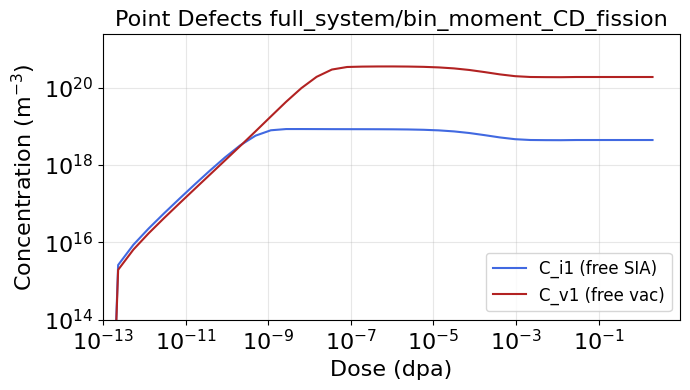

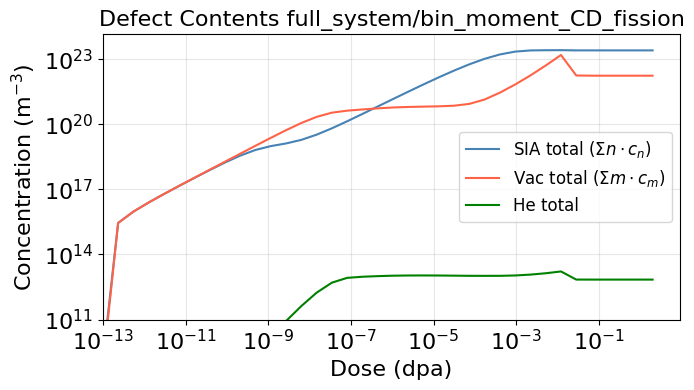

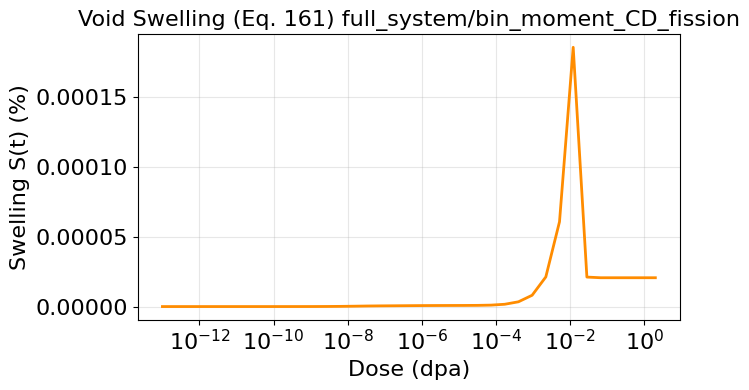

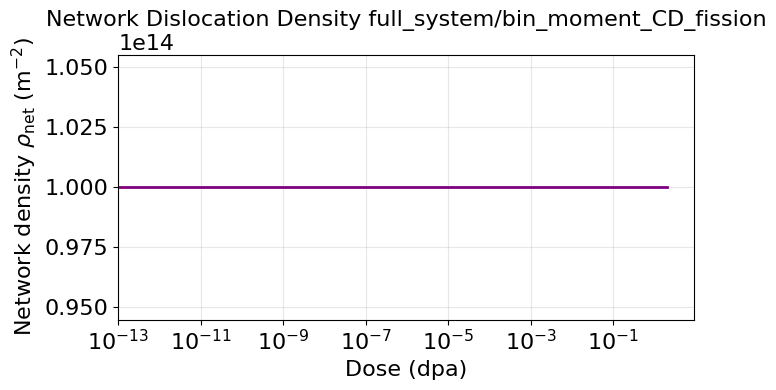

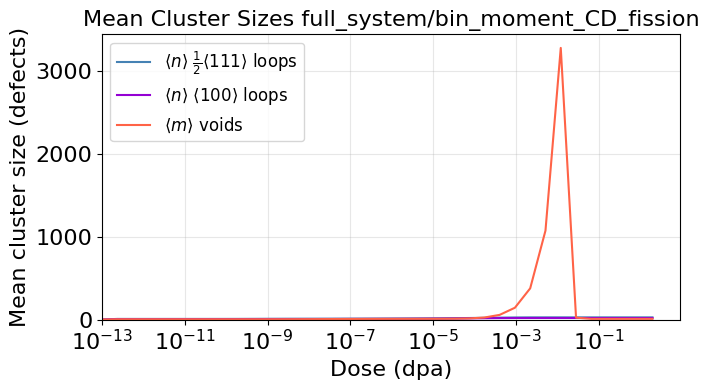

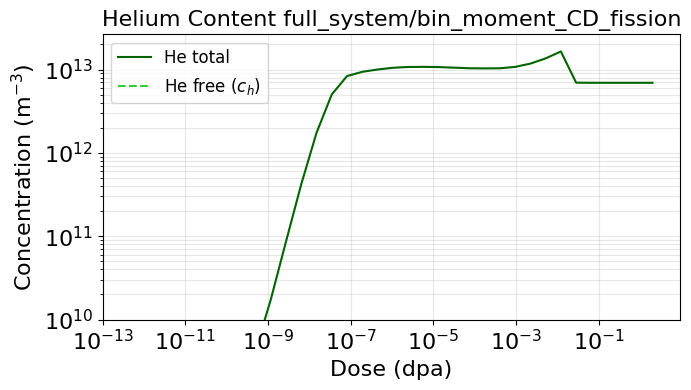

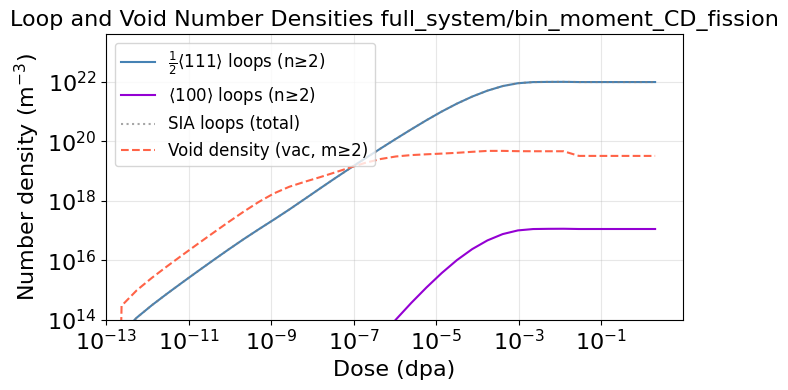

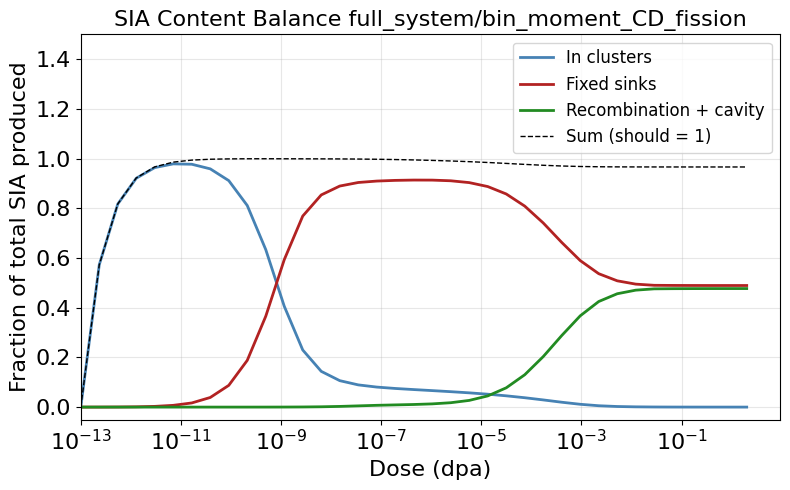

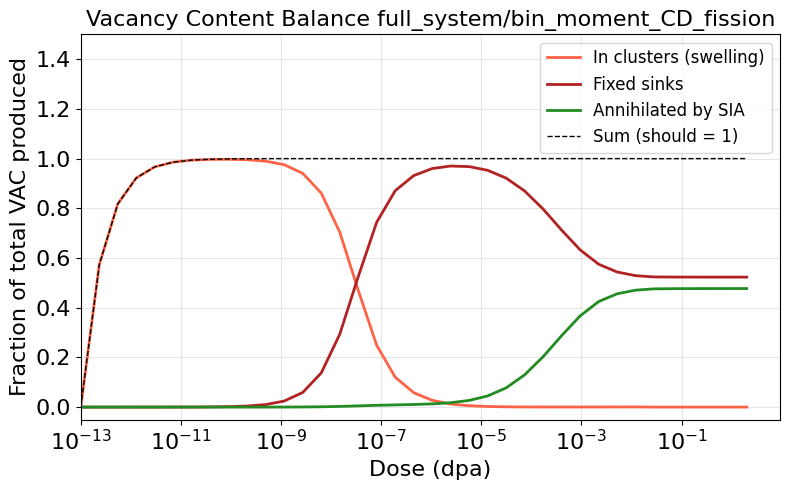

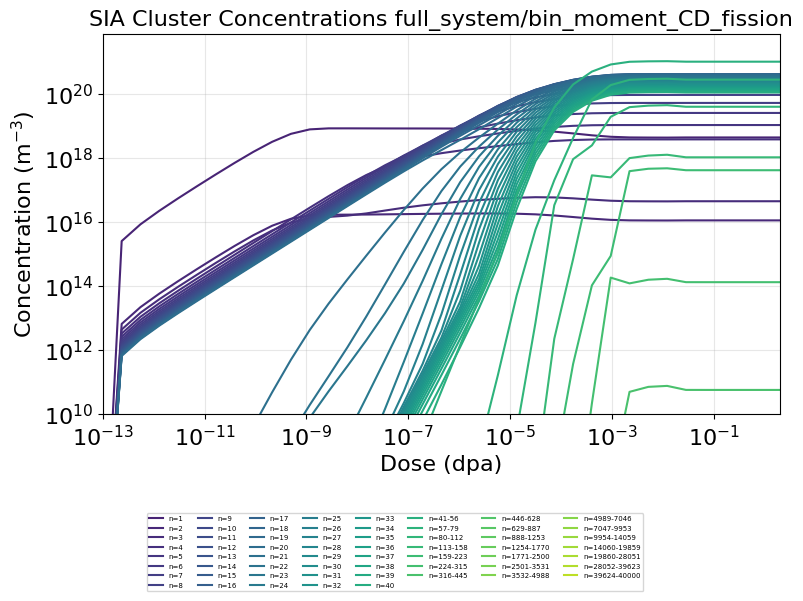

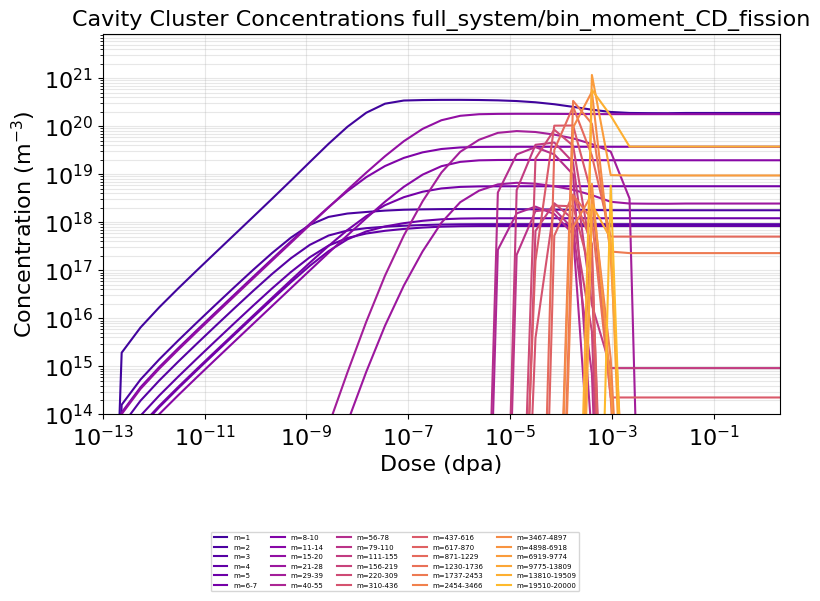

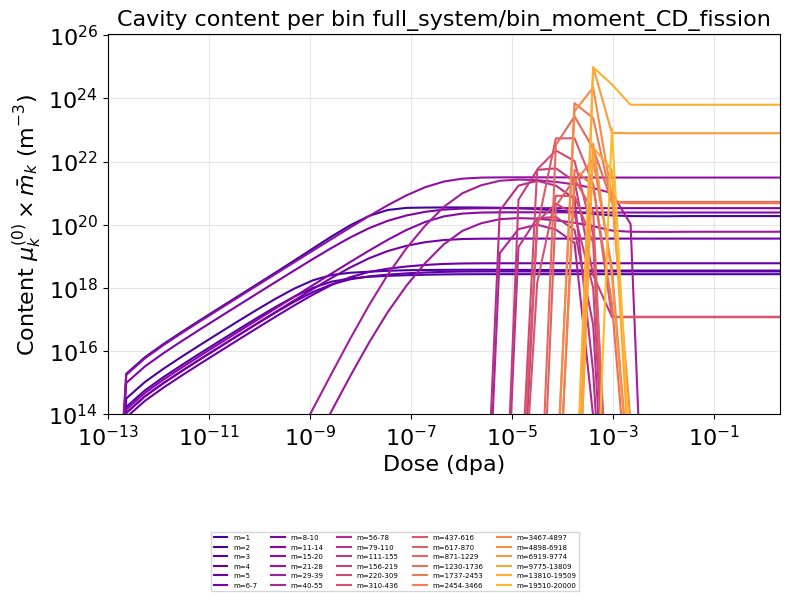

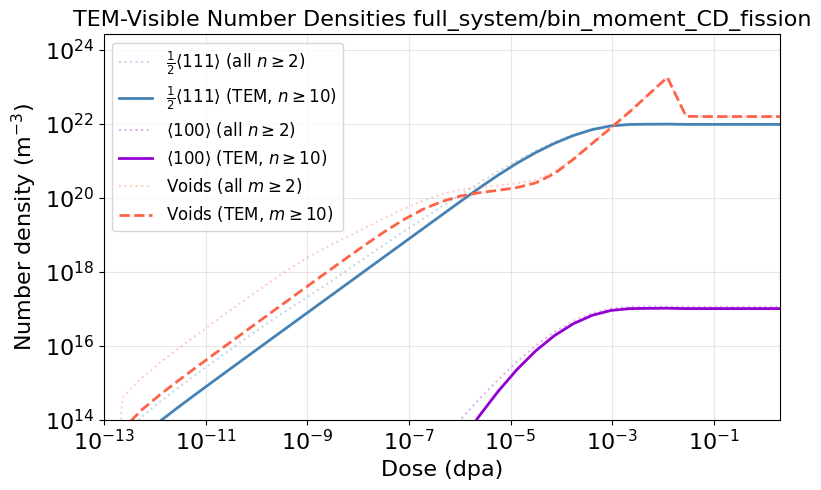

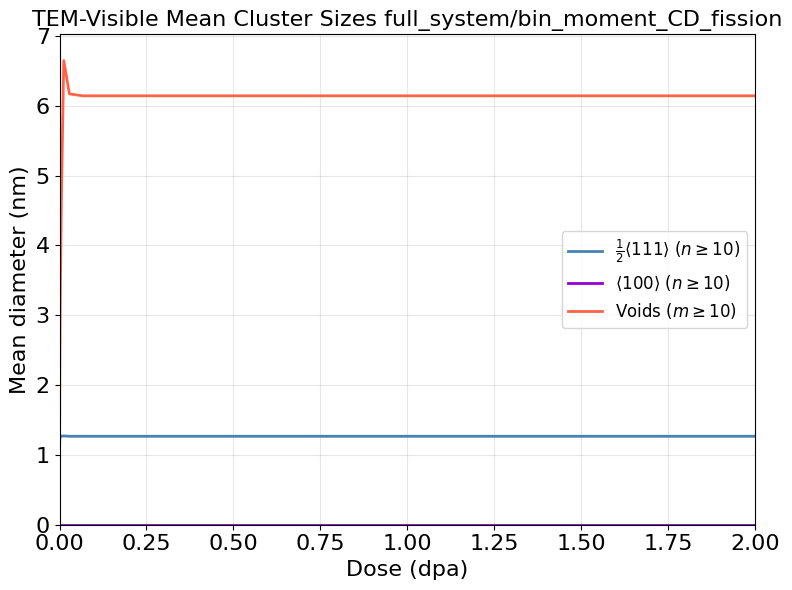

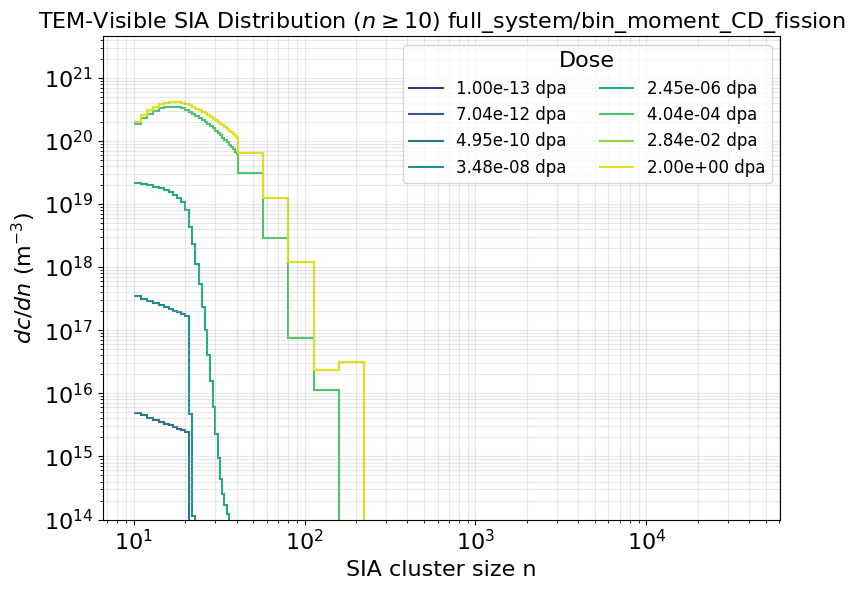

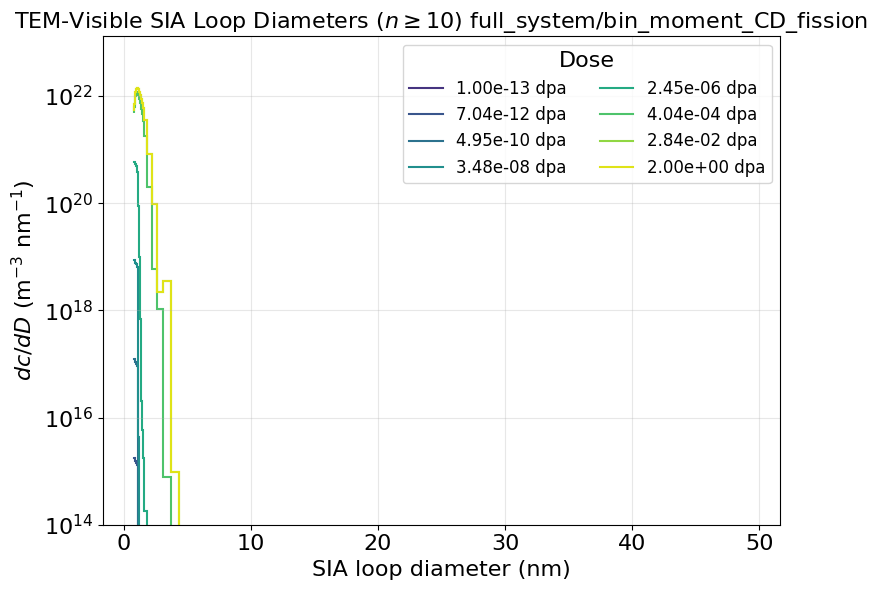

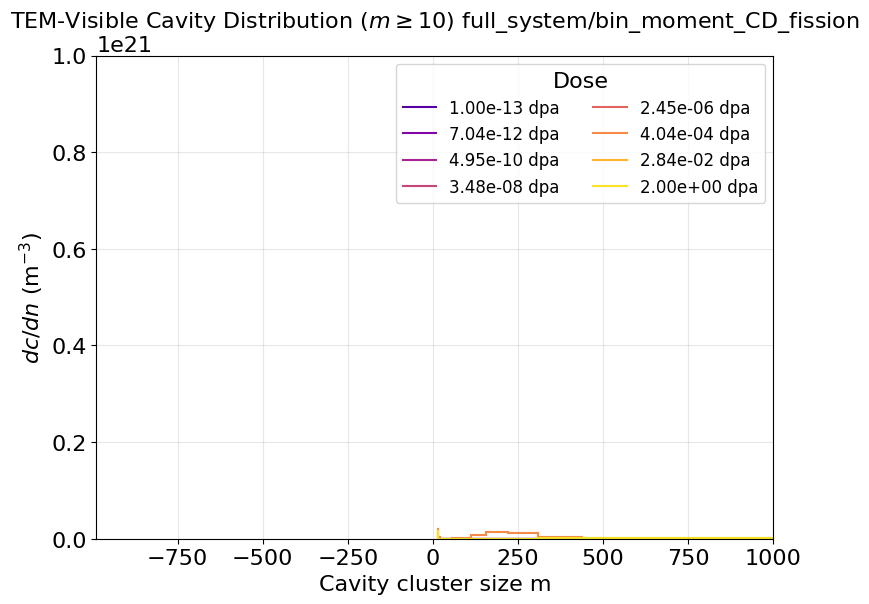

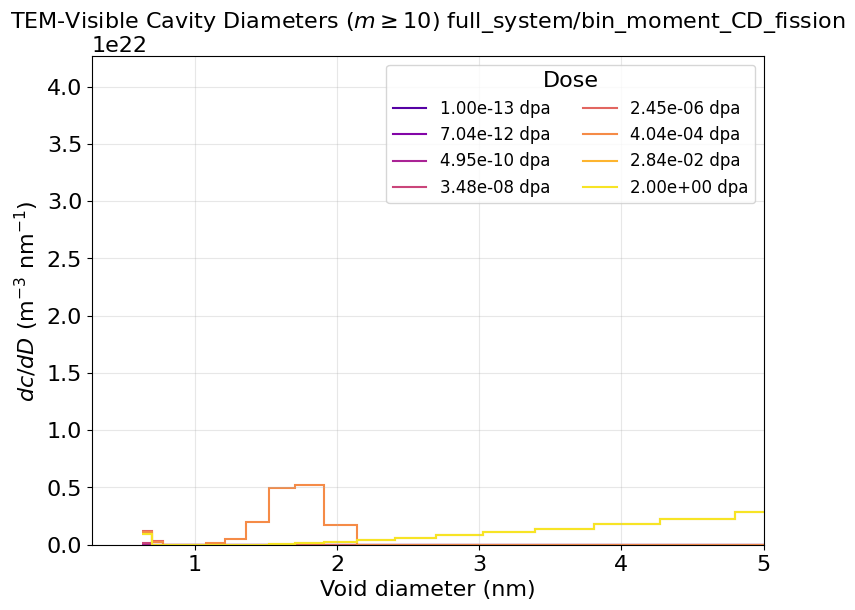

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# REPLOT FROM SAVED DATA — adjust axes without re-running the simulation
# ══════════════════════════════════════════════════════════════════════════════
# This cell reads `plot_data.pkl` (auto-saved by `save_all_plots` next to the
# PNGs) and re-renders every figure with user-controlled axis limits/scales.
# Edit the kwargs in each section and re-run only this cell — no solver call.
#
# Pin a specific run by setting PLOT_DATA_PATH to its absolute path; leave
# None to auto-pick the most-recent output directory.
# ══════════════════════════════════════════════════════════════════════════════
import pickle
from pathlib import Path
import matplotlib.pyplot as plt

PLOT_DATA_PATH = None   # str or Path; None = auto-pick latest

if PLOT_DATA_PATH is None:
    output_root = MODULE_ROOT / 'output'
    candidates = sorted(output_root.glob('*/plots/plot_data.pkl'))
    if not candidates:
        raise FileNotFoundError(f'No plot_data.pkl found under {output_root}')
    PLOT_DATA_PATH = candidates[-1]

print(f'Loading plot data: {PLOT_DATA_PATH}')
_pd = viz.load_plot_data(PLOT_DATA_PATH)
results     = _pd['results']
input_data  = _pd['input_data']
rate_eq_obj = _pd['rate_eq_obj']
label       = _pd.get('label', '')


def _replot(plot_fn, *args, xlim=(None, None), ylim=(None, None),
            xscale=None, yscale=None, **kwargs):
    """Call a plot function, then override every axis's limits/scales.

    Robust to plot functions that return a single Figure, a list/tuple of
    Figures, or None; a plot function that raises is reported and skipped
    so one bad figure cannot abort the whole replot cell.
    """
    try:
        out = plot_fn(*args, title=label, **kwargs)
    except Exception as exc:                       # noqa: BLE001
        print(f'  {plot_fn.__name__}: skipped ({type(exc).__name__}: {exc})')
        return None
    if out is None:
        print(f'  {plot_fn.__name__}: skipped (no data for this run)')
        return None
    figs = list(out) if isinstance(out, (list, tuple)) else [out]
    for fig in figs:
        if fig is None or not hasattr(fig, 'axes'):
            continue
        for ax in fig.axes:
            if xscale is not None:
                ax.set_xscale(xscale)
            if yscale is not None:
                ax.set_yscale(yscale)
            ax.set_xlim(left=xlim[0], right=xlim[1])
            ax.set_ylim(bottom=ylim[0], top=ylim[1])
        if fig.canvas is not None:
            fig.canvas.draw_idle()
    return out


# ── Point Defects ─────────────────────────────────────────────────────────
_replot(viz.plot_point_defects, results,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Defect Contents (totals: SIA, vacancy, He) ────────────────────────────
_replot(viz.plot_totals, results,
        xlim=(None, None), ylim=(1e11, None),
        xscale=None, yscale=None)

# ── Void Swelling vs Dose ─────────────────────────────────────────────────
_replot(viz.plot_swelling, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# -- Network Dislocation Density vs Dose (loop -> network loss) --
_replot(viz.plot_network_density, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── Mean Cluster Sizes (all sizes) ────────────────────────────────────────
_replot(viz.plot_mean_sizes, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── He Content ────────────────────────────────────────────────────────────
_replot(viz.plot_he_content, results,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── Number Densities (loops + voids, all sizes) ───────────────────────────
_replot(viz.plot_number_densities, results,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── SIA Fraction Breakdown ────────────────────────────────────────────────
_replot(viz.plot_sia_fraction_breakdown, results,
        xlim=(None, None), ylim=(None, 1.5),
        xscale=None, yscale=None)

# ── Vacancy Fraction Breakdown ────────────────────────────────────────────
_replot(viz.plot_vac_fraction_breakdown, results,
        xlim=(None, None), ylim=(None, 1.5),
        xscale=None, yscale=None)

# ── Size Distributions (snapshot at final time) ───────────────────────────
_replot(viz.plot_size_distribution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None,
        t_idx=-1)

# ── SIA Distribution Evolution (per-size, full range) ─────────────────────
_replot(viz.plot_sia_distribution_evolution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Void Distribution Evolution (per-size, full range) ────────────────────
_replot(viz.plot_void_distribution_evolution, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── SIA Per-Cluster Timelines (full_CD modes only) ────────────────────────
_replot(viz.plot_sia_clusters, results, input_data,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Vacancy Per-Cluster Timelines (full_CD modes only) ────────────────────
_replot(viz.plot_vac_clusters, results, input_data,
        xlim=(None, None), ylim=(None, None),
        xscale=None, yscale=None)

# ── SIA Cluster Concentrations vs Dose (discrete + bin μ₀) ────────────────
_replot(viz.plot_sia_conc_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e10, None),
        xscale=None, yscale=None)

# ── Cavity Cluster Concentrations vs Dose (discrete + bin μ₀) ─────────────
_replot(viz.plot_vac_conc_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── Cavity Content per Bin vs Dose (μ₀ × m̄) ──────────────────────────────
_replot(viz.plot_vac_content_vs_dose, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Number Densities (n,m ≥ 10) ───────────────────────────────
_replot(viz.plot_number_densities_tem, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Mean Cluster Sizes (combined SIA + void) ──────────────────
_replot(viz.plot_mean_sizes_tem, results, input_data, rate_eq_obj,
        xlim=(0, None), ylim=(0, None),
        xscale='linear', yscale='linear')

# ── TEM-Visible SIA Distribution vs Cluster Size ──────────────────────────
_replot(viz.plot_sia_distribution_tem_size, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible SIA Distribution vs Loop Diameter ─────────────────────────
_replot(viz.plot_sia_distribution_tem_diameter, results, input_data, rate_eq_obj,
        xlim=(None, None), ylim=(1e14, None),
        xscale=None, yscale=None)

# ── TEM-Visible Cavity Distribution vs Cluster Size ───────────────────────
_replot(viz.plot_vac_distribution_tem_size, results, input_data, rate_eq_obj,
        xlim=(None, 1e3), ylim=(None, 1e21),
        xscale='linear', yscale='linear')

# ── TEM-Visible Cavity Distribution vs Void Diameter ──────────────────────
_replot(viz.plot_vac_distribution_tem_diameter, results, input_data, rate_eq_obj,
        xlim=(None, 5), ylim=(None, None),
        xscale='linear', yscale='linear')

plt.show()
